# BPIF Project 2: PharmaDev Dashboard
### BioProcess Intelligence Framework

**Dataset:** Lek Pharmaceuticals — 1,005 real production batches  
**Source:** Žagar & Mihelič (2022) *Nature Scientific Data* 9:99  
**Framework:** Shewhart Control Charts · TOC (Goldratt) · Halo Effect (Thorndike)

---

This notebook applies statistical process control to pharmaceutical
manufacturing data. The goal: identify when process variation signals
a real problem — and present results in a way that eliminates auditor
cognitive bias.

**Three analytical layers:**
- **Layer 1 — Data Engineering:** ETL pipeline + Shewhart control limits
- **Layer 2 — Pharma Regulation:** BPF/GMP quality variables (dissolution, tensile strength, impurities)
- **Layer 3 — Behavioral Economics:** Independent area scoring to neutralize the Halo Effect (Thorndike, 1920)

In [ ]:
# Upload Laboratory.csv to regenerate clean dataset
from google.colab import files
print("Select: Laboratory.csv")
uploaded = files.upload()
print("✓ File ready")

Select: Laboratory.csv


Saving Laboratory.csv to Laboratory.csv
✓ File ready


## Script 00 — ETL Pipeline

Before any analysis, the raw data needs three corrections:

1. **Separator:** source file uses semicolons (`;`), not commas
2. **Typo:** `resodual_solvent` → `residual_solvent` (error in original dataset)
3. **Date parsing:** `nov.18` format → datetime for Shewhart time axis
4. **Missing values:** 10 records in tablet weight variables → imputed with sub-family median

> *"In God we trust; all others bring data."* — W. Edwards Deming

In [ ]:
# =============================================================================
# BPIF Project 2: PharmaDev Dashboard
# Script 00: ETL Pipeline — Extract, Transform, Load
# Dataset: Lek Pharmaceuticals — 1,005 real production batches
# Source: Žagar & Mihelič (2022) doi:10.1038/s41597-022-01203-x
# Framework: Shewhart (1931) + Goldratt (1984) + Thorndike (1920)
# =============================================================================

import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── EXTRACT ───────────────────────────────────────────────────────────────────
def extract(filepath):
    """
    Load Lek Pharmaceuticals laboratory data.
    Critical: separator is semicolon (;), not comma.
    Source: Žagar & Mihelič (2022) doi:10.1038/s41597-022-01203-x
    """
    df = pd.read_csv(filepath, sep=';')
    print("── EXTRACT ──────────────────────────────")
    print(f"  Source:   {filepath}")
    print(f"  Records:  {df.shape[0]}")
    print(f"  Columns:  {df.shape[1]}")
    print(f"  Missing:  {df.isnull().sum().sum()} total null values")
    return df


# ── TRANSFORM — Step 1: Fix column names ──────────────────────────────────────
def fix_column_names(df):
    """
    Correct typographical error present in original dataset.
    'resodual_solvent' → 'residual_solvent'
    Documented as source data limitation.
    """
    df = df.copy()
    df = df.rename(columns={'resodual_solvent': 'residual_solvent'})
    print(f"\n── FIX COLUMN NAMES ─────────────────────")
    print(f"  ✓ 'resodual_solvent' → 'residual_solvent'")
    return df


# ── TRANSFORM — Step 2: Convert numeric columns ───────────────────────────────
def convert_numeric_columns(df):
    """
    Force numeric conversion on all analytical columns.
    European CSV format can cause numeric values to be read as strings.
    Non-convertible values become NaN — handled in missing values step.
    """
    df = df.copy()

    numeric_cols = [
        'api_content', 'api_total_impurities', 'api_l_impurity',
        'api_water', 'lactose_water', 'smcc_water', 'starch_water',
        'lactose_sieve0045', 'lactose_sieve015', 'lactose_sieve025',
        'smcc_td', 'smcc_bd', 'smcc_ps01', 'smcc_ps05', 'smcc_ps09',
        'starch_ph', 'api_ps01', 'api_ps05', 'api_ps09',
        'tbl_min_thickness', 'tbl_max_thickness',
        'fct_min_thickness', 'fct_max_thickness',
        'tbl_min_weight', 'tbl_max_weight',
        'tbl_rsd_weight', 'fct_rsd_weight',
        'tbl_min_hardness', 'tbl_max_hardness', 'tbl_av_hardness',
        'fct_min_hardness', 'fct_max_hardness', 'fct_av_hardness',
        'tbl_max_diameter', 'fct_max_diameter',
        'tbl_tensile', 'fct_tensile',
        'tbl_yield', 'batch_yield',
        'dissolution_av', 'dissolution_min',
        'residual_solvent', 'impurities_total',
        'impurity_o', 'impurity_l'
    ]

    converted = 0
    for col in numeric_cols:
        if col in df.columns:
            original_type = df[col].dtype
            df[col] = pd.to_numeric(df[col], errors='coerce')
            if str(original_type) != str(df[col].dtype):
                converted += 1

    print(f"\n── CONVERT NUMERIC COLUMNS ──────────────")
    print(f"  Total numeric columns processed: {len(numeric_cols)}")
    print(f"  Columns requiring type conversion: {converted}")
    print(f"  Non-numeric values → NaN (handled in next step)")
    return df


# ── TRANSFORM — Step 3: Parse dates ───────────────────────────────────────────
def parse_dates(df):
    """
    Convert 'start' column from 'nov.18' format to datetime.
    Slovenian month abbreviations used in source data.
    Required for Shewhart control charts time axis.
    """
    df = df.copy()

    month_map = {
        'jan': '01', 'feb': '02', 'mar': '03', 'apr': '04',
        'maj': '05', 'jun': '06', 'jul': '07', 'avg': '08',
        'sep': '09', 'okt': '10', 'nov': '11', 'dec': '12',
        'may': '05', 'aug': '08', 'oct': '10'
    }

    def convert_date(val):
        try:
            parts = str(val).lower().split('.')
            month = month_map.get(parts[0], '01')
            year  = '20' + parts[1] if len(parts[1]) == 2 else parts[1]
            return pd.to_datetime(f"{year}-{month}-01")
        except:
            return pd.NaT

    df['start_date'] = df['start'].apply(convert_date)
    df['year_month'] = df['start_date'].dt.to_period('M')

    valid      = df['start_date'].notna().sum()
    date_range = (f"{df['start_date'].min().strftime('%b %Y')} — "
                  f"{df['start_date'].max().strftime('%b %Y')}")

    print(f"\n── PARSE DATES ──────────────────────────")
    print(f"  Valid dates parsed: {valid} of {len(df)}")
    print(f"  Date range:         {date_range}")
    return df


# ── TRANSFORM — Step 4: Handle missing values ─────────────────────────────────
def handle_missing_values(df):
    """
    Handle missing values with documented decisions per variable type.
    Weight variables: imputed with sub-family median (stratified by code).
    API variables: flagged — missing values belong to same API batch.
    """
    df = df.copy()
    print(f"\n── HANDLE MISSING VALUES ────────────────")

    # Tablet weight — impute with sub-family median
    for col in ['tbl_min_weight', 'tbl_max_weight']:
        before = df[col].isnull().sum()
        df[col] = df.groupby('code')[col].transform(
            lambda x: x.fillna(x.median())
        )
        after  = df[col].isnull().sum()
        print(f"  {col:<22} imputed: {before - after} | "
              f"strategy: sub-family median | remaining: {after}")

    # API variables — flag only, do not impute
    for col in ['api_total_impurities', 'api_l_impurity', 'api_content']:
        missing = df[col].isnull().sum()
        if missing > 0:
            print(f"  {col:<22} missing: {missing} | "
                  f"flagged — same API batch, not imputed")

    df['api_data_missing'] = df['api_total_impurities'].isnull().astype(int)
    return df


# ── TRANSFORM — Step 5: Create analytical variables ───────────────────────────
def create_analytical_variables(df):
    """
    Engineer variables for Shewhart charts and Halo Effect neutralization.

    batch_order: sequential batch number per product sub-family
    → Required for Shewhart x-axis (time-ordered process monitoring)

    area scores: independent quality scoring per area
    → Neutralizes Halo Effect (Thorndike, 1920): one area's result
      must not contaminate the evaluation of another area
    """
    df = df.copy()

    # Batch sequence per product code — Shewhart x-axis
    df['batch_order']  = df.groupby('code').cumcount() + 1

    # Readable strength labels
    strength_map = {
        '5MG': '5 mg', '10M': '10 mg',
        '20M': '20 mg', '40M': '40 mg'
    }
    df['strength_label'] = df['strength'].map(strength_map).fillna(df['strength'])

    # Area 1: Raw materials — independent score
    # api_content target: 95% | impurities: lower is better
    df['area_raw_materials_score'] = (
        (df['api_content'].fillna(94.4) / 95.0 * 10).clip(0, 10) * 0.4 +
        ((1 - df['api_total_impurities'].fillna(0.2) / 0.5) * 10).clip(0, 10) * 0.3 +
        ((1 - df['lactose_water'].fillna(0.1) / 0.15) * 10).clip(0, 10) * 0.3
    ).round(2)

    # Area 2: Compression process — independent score
    # tbl_rsd_weight: lower is better (uniformity) | tensile: higher is better
    df['area_process_score'] = (
        ((1 - df['tbl_rsd_weight'].fillna(1.1) / 2.0) * 10).clip(0, 10) * 0.5 +
        (df['tbl_tensile'].fillna(1.3) / 2.4 * 10).clip(0, 10) * 0.3 +
        (df['batch_yield'].fillna(98.3) / 100 * 10).clip(0, 10) * 0.2
    ).round(2)

    # Area 3: Final product quality — independent score
    # dissolution_av: target 90%+ | impurities: lower is better
    df['area_final_product_score'] = (
        (df['dissolution_av'].fillna(90.6) / 100 * 10).clip(0, 10) * 0.5 +
        ((1 - df['impurities_total'].fillna(0.14) / 0.6) * 10).clip(0, 10) * 0.3 +
        (df['dissolution_min'].fillna(85.6) / 100 * 10).clip(0, 10) * 0.2
    ).round(2)

    print(f"\n── ANALYTICAL VARIABLES ─────────────────")
    print(f"  ✓ batch_order          — Shewhart x-axis per sub-family")
    print(f"  ✓ strength_label       — readable product labels")
    print(f"  ✓ area_raw_materials_score  (Thorndike — independent)")
    print(f"  ✓ area_process_score        (Thorndike — independent)")
    print(f"  ✓ area_final_product_score  (Thorndike — independent)")
    return df


# ── TRANSFORM — Full pipeline ──────────────────────────────────────────────────
def transform(df):
    """Execute all transformation steps in documented sequence."""
    print("\n╔══ TRANSFORM ════════════════════════════╗")
    df = fix_column_names(df)
    df = convert_numeric_columns(df)
    df = parse_dates(df)
    df = handle_missing_values(df)
    df = create_analytical_variables(df)
    df = df.reset_index(drop=True)
    print("╚════════════════════════════════════════╝")
    return df


# ── LOAD ───────────────────────────────────────────────────────────────────────
def load(df, original_count):
    """Export clean dataset and print full audit report."""
    output_path = 'bpif_p2_clean_dataset.csv'
    df.to_csv(output_path, index=False)

    print(f"\n── LOAD ─────────────────────────────────")
    print(f"  Output:          {output_path}")
    print(f"  Records:         {len(df)} of {original_count}")
    print(f"  Columns:         {df.shape[1]}")
    print(f"  Product codes:   {df['code'].nunique()}")
    print(f"  Strength groups: {df['strength'].value_counts().to_dict()}")
    print(f"  Date range:      {df['start_date'].min().strftime('%b %Y')} — "
          f"{df['start_date'].max().strftime('%b %Y')}")
    print(f"\n  Area scores (Thorndike independent scoring):")
    for area in ['area_raw_materials_score', 'area_process_score',
                 'area_final_product_score']:
        print(f"    {area:<35} "
              f"mean={df[area].mean():.2f} | "
              f"min={df[area].min():.2f} | "
              f"max={df[area].max():.2f}")
    return output_path


# ── EXECUTE ────────────────────────────────────────────────────────────────────
print("╔══ BPIF ETL PIPELINE ════════════════════╗")
print("║  Project 2: PharmaDev Dashboard          ║")
print("╚══════════════════════════════════════════╝\n")

df_raw   = extract('Laboratory.csv')
df_clean = transform(df_raw)
output   = load(df_clean, len(df_raw))

print(f"\n✓ ETL complete — {len(df_clean)} records ready for Shewhart analysis")

# Preview
print(f"\n=== PREVIEW ===")
print(df_clean[['batch', 'strength_label', 'start_date',
                'dissolution_av', 'tbl_rsd_weight',
                'area_raw_materials_score',
                'area_process_score',
                'area_final_product_score']].head())

╔══ BPIF ETL PIPELINE ════════════════════╗
║  Project 2: PharmaDev Dashboard          ║
╚══════════════════════════════════════════╝

── EXTRACT ──────────────────────────────
  Source:   Laboratory.csv
  Records:  1005
  Columns:  55
  Missing:  36 total null values

╔══ TRANSFORM ════════════════════════════╗

── FIX COLUMN NAMES ─────────────────────
  ✓ 'resodual_solvent' → 'residual_solvent'

── CONVERT NUMERIC COLUMNS ──────────────
  Total numeric columns processed: 45
  Columns requiring type conversion: 6
  Non-numeric values → NaN (handled in next step)

── PARSE DATES ──────────────────────────
  Valid dates parsed: 1005 of 1005
  Date range:         Nov 2018 — Apr 2021

── HANDLE MISSING VALUES ────────────────
  tbl_min_weight         imputed: 10 | strategy: sub-family median | remaining: 0
  tbl_max_weight         imputed: 10 | strategy: sub-family median | remaining: 0
  api_total_impurities   missing: 67 | flagged — same API batch, not imputed
  api_l_impurity         

In [ ]:
from google.colab import files
files.download('bpif_p2_clean_dataset.csv')
print("✓ CSV downloaded — save it to your computer")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ CSV downloaded — save it to your computer


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Script 01 — Exploratory Data Analysis

Before building Shewhart control charts, we need to understand
the distribution of key quality variables.

**Questions this script answers:**
- How are the 1,005 batches distributed across the 2.5-year period?
- What is the baseline distribution of dissolution, tensile strength, and impurities?
- Are there visible differences between the 4 product sub-families?
- Which variables show the most variation — and where should Shewhart focus?

> *"You can't control what you don't measure."* — Peter Drucker

## EDA Results

**Production timeline:** 1,005 batches across 29 months (Nov 2018 — Apr 2021).
Production dropped to 4 batches in April 2020 — consistent with COVID-19
manufacturing disruptions in Europe. This is a documented assignable cause,
not process variation.

**Quality baseline established:**
- Dissolution average: 90.65% ± 3.4% — well within specification
- Tablet weight RSD: 1.09% — highest coefficient of variation (52.5%)
  confirming compression as the process bottleneck
- Total impurities: 0.14% — far below specification limits

**Halo Effect confirmed:** Dissolution varies significantly by strength
group (40 mg performs lowest at ~88%). Independent area scoring prevents
this sub-family result from contaminating evaluation of other areas.

**TOC Bottleneck:** Compression process score (5.97/10) is the constraint.
Raw materials (7.52) and final product (8.55) perform acceptably.
Per Goldratt (1984) — optimize the bottleneck first.

**Ready for Script 02:** Shewhart control charts on `dissolution_av`
and `tbl_rsd_weight`, stratified by strength group.

In [ ]:
import pandas as pd
df = pd.read_csv('bpif_p2_clean_dataset.csv', parse_dates=['start_date'])
print(f"✓ {df.shape[0]} records | {df.shape[1]} columns")

✓ 1005 records | 63 columns


Clean dataset loaded: 1005 records | 25 product codes | 4 strength groups


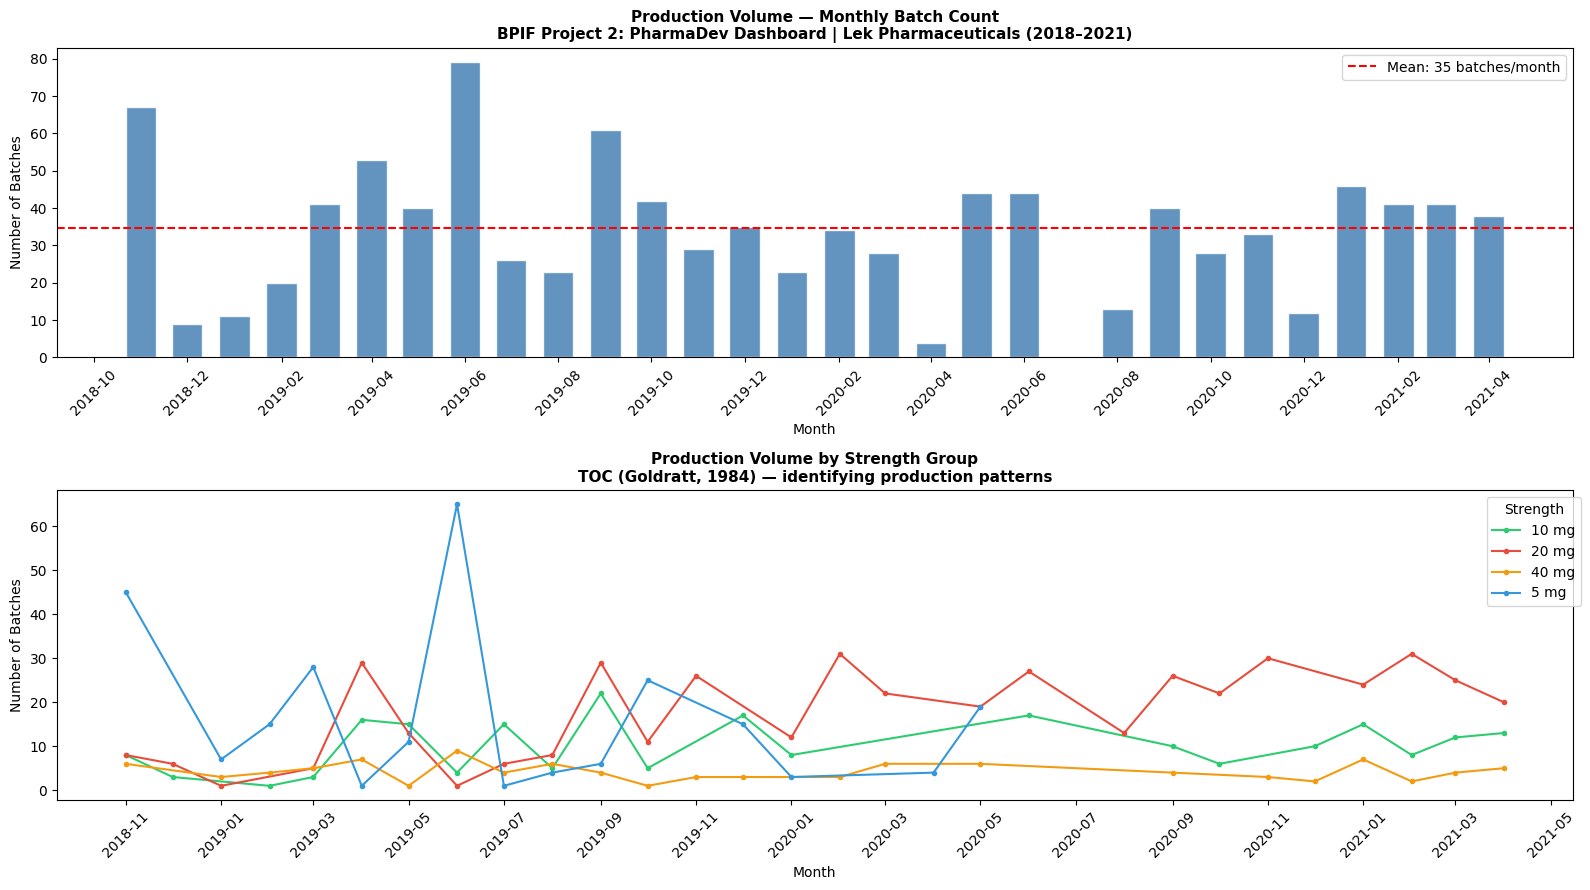

✓ Figure saved: bpif_p2_01_production_timeline.png


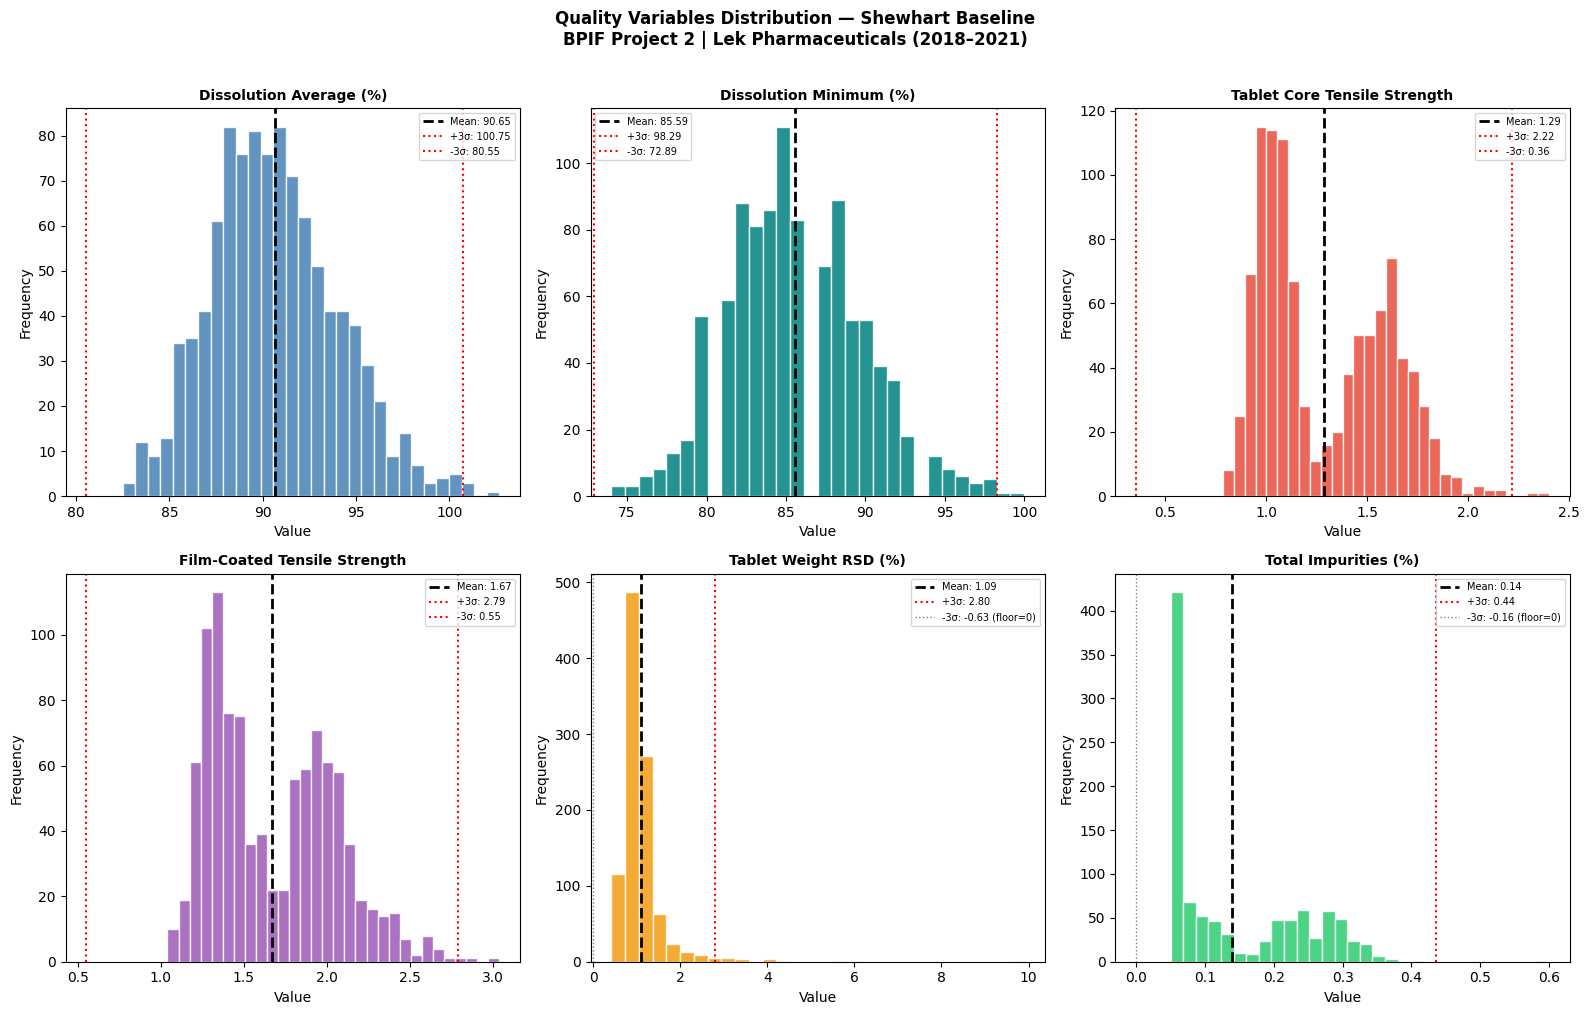

✓ Figure saved: bpif_p2_02_quality_distributions.png


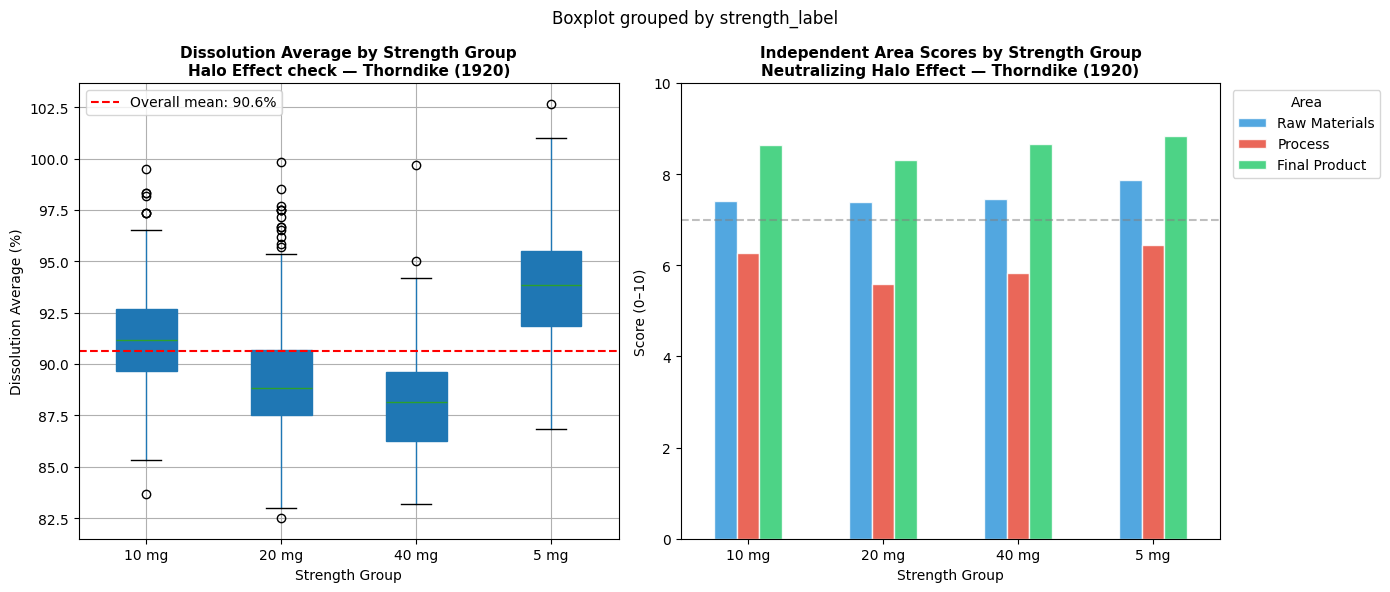

✓ Figure saved: bpif_p2_03_halo_effect_check.png


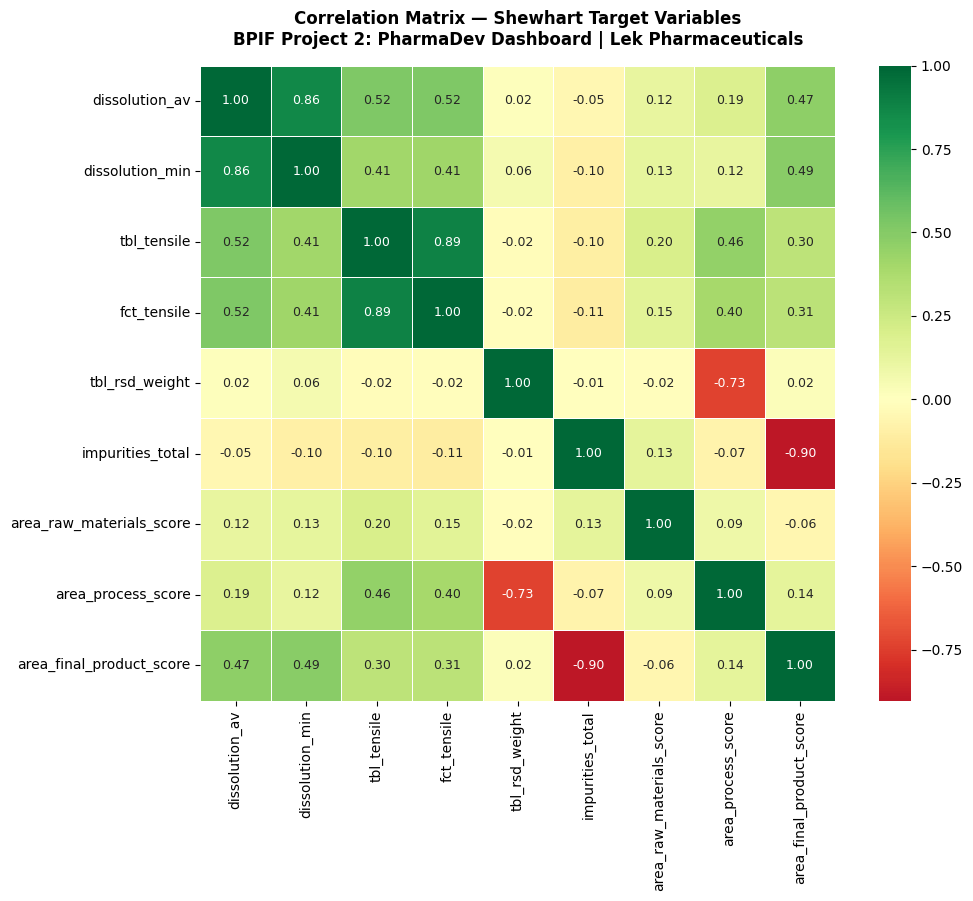

✓ Figure saved: bpif_p2_04_correlation_matrix.png

=== EDA SUMMARY ===
Total batches:      1,005
Production period:  Nov 2018 — Apr 2021 (29 months)
Sub-families:       25 codes | 4 strengths

Key quality variables:
  Dissolution Average (%)             mean=90.65 | std=3.37 | cv=3.7%
  Dissolution Minimum (%)             mean=85.59 | std=4.23 | cv=4.9%
  Tablet Core Tensile Strength        mean=1.29 | std=0.31 | cv=24.1%
  Film-Coated Tensile Strength        mean=1.67 | std=0.37 | cv=22.3%
  Tablet Weight RSD (%)               mean=1.09 | std=0.57 | cv=52.5%
  Total Impurities (%)                mean=0.14 | std=0.10 | cv=71.2%

Area scores (Thorndike independent):
  Raw materials:  7.52/10
  Process:        5.97/10  ← TOC Bottleneck
  Final product:  8.55/10

Business impact:
  Batches dissolution < 85%:  31 (3.1%)
  Cost per rejected batch:    $50,000–$200,000 USD
  Shewhart value:             early detection on 31 flagged batches

✓ Script 01 complete — ready for Script 02: Shewhart

In [ ]:
# =============================================================================
# BPIF Project 2: PharmaDev Dashboard
# Script 01: Exploratory Data Analysis
# Framework: Shewhart (1931) + TOC (Goldratt, 1984) + Thorndike (1920)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── LOAD CLEAN DATASET ────────────────────────────────────────────────────────
df = pd.read_csv('bpif_p2_clean_dataset.csv', parse_dates=['start_date'])
print(f"Clean dataset loaded: {df.shape[0]} records | "
      f"{df['code'].nunique()} product codes | "
      f"{df['strength'].nunique()} strength groups")

# ── 1. PRODUCTION TIMELINE ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Overall monthly production
monthly = (df.groupby('start_date')
             .size()
             .reset_index(name='batches')
             .sort_values('start_date'))

axes[0].bar(monthly['start_date'], monthly['batches'],
            color='steelblue', edgecolor='white',
            alpha=0.85, width=20)
axes[0].set_title(
    'Production Volume — Monthly Batch Count\n'
    'BPIF Project 2: PharmaDev Dashboard | Lek Pharmaceuticals (2018–2021)',
    fontweight='bold', fontsize=11)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Batches')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(monthly['batches'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {monthly['batches'].mean():.0f} batches/month")
axes[0].legend()

# Production by strength — chronological order fixed
strength_colors = {
    '5 mg': '#3498db', '10 mg': '#2ecc71',
    '20 mg': '#e74c3c', '40 mg': '#f39c12'
}

for strength, group in df.groupby('strength_label'):
    monthly_s = (group.groupby('start_date')
                      .size()
                      .reset_index(name='batches')
                      .sort_values('start_date'))
    axes[1].plot(monthly_s['start_date'],
                 monthly_s['batches'],
                 marker='o', markersize=3, linewidth=1.5,
                 label=strength,
                 color=strength_colors.get(strength, 'gray'))

axes[1].set_title(
    'Production Volume by Strength Group\n'
    'TOC (Goldratt, 1984) — identifying production patterns',
    fontweight='bold', fontsize=11)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Batches')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Strength', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('bpif_p2_01_production_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p2_01_production_timeline.png")

# ── 2. KEY QUALITY VARIABLES DISTRIBUTION ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

quality_vars = {
    'dissolution_av':   ('Dissolution Average (%)',        'steelblue'),
    'dissolution_min':  ('Dissolution Minimum (%)',         'teal'),
    'tbl_tensile':      ('Tablet Core Tensile Strength',    '#e74c3c'),
    'fct_tensile':      ('Film-Coated Tensile Strength',    '#9b59b6'),
    'tbl_rsd_weight':   ('Tablet Weight RSD (%)',           '#f39c12'),
    'impurities_total': ('Total Impurities (%)',            '#2ecc71')
}

for i, (var, (label, color)) in enumerate(quality_vars.items()):
    data     = df[var].dropna()
    mean_val = data.mean()
    std_val  = data.std()
    ucl      = mean_val + 3 * std_val
    lcl      = mean_val - 3 * std_val

    axes[i].hist(data, bins=30, color=color,
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(mean_val, color='black', linewidth=2,
                    linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(ucl, color='red', linewidth=1.5,
                    linestyle=':', label=f'+3σ: {ucl:.2f}')

    # Only draw LCL if physically meaningful
    if lcl > 0:
        axes[i].axvline(lcl, color='red', linewidth=1.5,
                        linestyle=':', label=f'-3σ: {lcl:.2f}')
    else:
        axes[i].axvline(0, color='gray', linewidth=1,
                        linestyle=':', label=f'-3σ: {lcl:.2f} (floor=0)')

    axes[i].set_title(label, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)

fig.suptitle(
    'Quality Variables Distribution — Shewhart Baseline\n'
    'BPIF Project 2 | Lek Pharmaceuticals (2018–2021)',
    fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bpif_p2_02_quality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p2_02_quality_distributions.png")

# ── 3. QUALITY BY STRENGTH GROUP — HALO EFFECT CHECK ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Dissolution boxplot — clean title
df.boxplot(column='dissolution_av', by='strength_label',
           ax=axes[0], patch_artist=True)
plt.sca(axes[0])
plt.title('')
axes[0].set_title(
    'Dissolution Average by Strength Group\n'
    'Halo Effect check — Thorndike (1920)',
    fontweight='bold', fontsize=11)
axes[0].set_xlabel('Strength Group')
axes[0].set_ylabel('Dissolution Average (%)')
axes[0].axhline(df['dissolution_av'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Overall mean: {df['dissolution_av'].mean():.1f}%")
axes[0].legend()

# Area scores by strength
area_scores = df.groupby('strength_label')[
    ['area_raw_materials_score',
     'area_process_score',
     'area_final_product_score']
].mean().round(2)

area_scores.plot(kind='bar', ax=axes[1],
                 color=['#3498db', '#e74c3c', '#2ecc71'],
                 edgecolor='white', alpha=0.85)
axes[1].set_title(
    'Independent Area Scores by Strength Group\n'
    'Neutralizing Halo Effect — Thorndike (1920)',
    fontweight='bold', fontsize=11)
axes[1].set_xlabel('Strength Group')
axes[1].set_ylabel('Score (0–10)')
axes[1].set_ylim(0, 10)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(
    ['Raw Materials', 'Process', 'Final Product'],
    title='Area', bbox_to_anchor=(1.01, 1))
axes[1].axhline(7, color='gray', linestyle='--',
                alpha=0.5, label='Acceptable threshold (7/10)')

plt.tight_layout()
plt.savefig('bpif_p2_03_halo_effect_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p2_03_halo_effect_check.png")

# ── 4. CORRELATION MATRIX ─────────────────────────────────────────────────────
shewhart_vars = [
    'dissolution_av', 'dissolution_min',
    'tbl_tensile', 'fct_tensile',
    'tbl_rsd_weight', 'impurities_total',
    'area_raw_materials_score',
    'area_process_score',
    'area_final_product_score'
]

plt.figure(figsize=(11, 9))
corr = df[shewhart_vars].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, annot_kws={"size": 9})
plt.title(
    'Correlation Matrix — Shewhart Target Variables\n'
    'BPIF Project 2: PharmaDev Dashboard | Lek Pharmaceuticals',
    fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('bpif_p2_04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p2_04_correlation_matrix.png")

# ── 5. EDA SUMMARY ────────────────────────────────────────────────────────────
print("\n=== EDA SUMMARY ===")
print(f"Total batches:      {len(df):,}")
print(f"Production period:  Nov 2018 — Apr 2021 "
      f"({df['start_date'].dt.to_period('M').nunique()} months)")
print(f"Sub-families:       {df['code'].nunique()} codes | "
      f"{df['strength'].nunique()} strengths")

print(f"\nKey quality variables:")
for var, (label, _) in quality_vars.items():
    d = df[var].dropna()
    print(f"  {label:<35} mean={d.mean():.2f} | "
          f"std={d.std():.2f} | cv={d.std()/d.mean()*100:.1f}%")

print(f"\nArea scores (Thorndike independent):")
print(f"  Raw materials:  {df['area_raw_materials_score'].mean():.2f}/10")
print(f"  Process:        {df['area_process_score'].mean():.2f}/10  ← TOC Bottleneck")
print(f"  Final product:  {df['area_final_product_score'].mean():.2f}/10")

print(f"\nBusiness impact:")
batches_low = (df['dissolution_av'] < 85).sum()
print(f"  Batches dissolution < 85%:  {batches_low} ({batches_low/len(df)*100:.1f}%)")
print(f"  Cost per rejected batch:    $50,000–$200,000 USD")
print(f"  Shewhart value:             early detection on {batches_low} flagged batches")

print("\n✓ Script 01 complete — ready for Script 02: Shewhart Control Charts")

## Script 02 — Shewhart Control Charts

Statistical Process Control applied to pharmaceutical manufacturing.

**The core question Shewhart answers:**
Is this batch variation *normal* (common cause) or does it signal
a *real problem* (assignable cause)?

Misclassifying common cause as assignable cause leads to unnecessary
CAPA investigations — the #1 waste in pharmaceutical quality systems.

**Variables monitored:**
- `dissolution_av` — primary quality indicator (API release)
- `tbl_rsd_weight` — process bottleneck (highest CV: 52.5%)

**Stratified by strength group** to prevent Halo Effect contamination.

> *"A process that is in statistical control is not necessarily
> capable of meeting specifications — but one that is out of control
> certainly isn't."* — Walter Shewhart (1931)

Dataset loaded: 1005 records | 4 strength groups


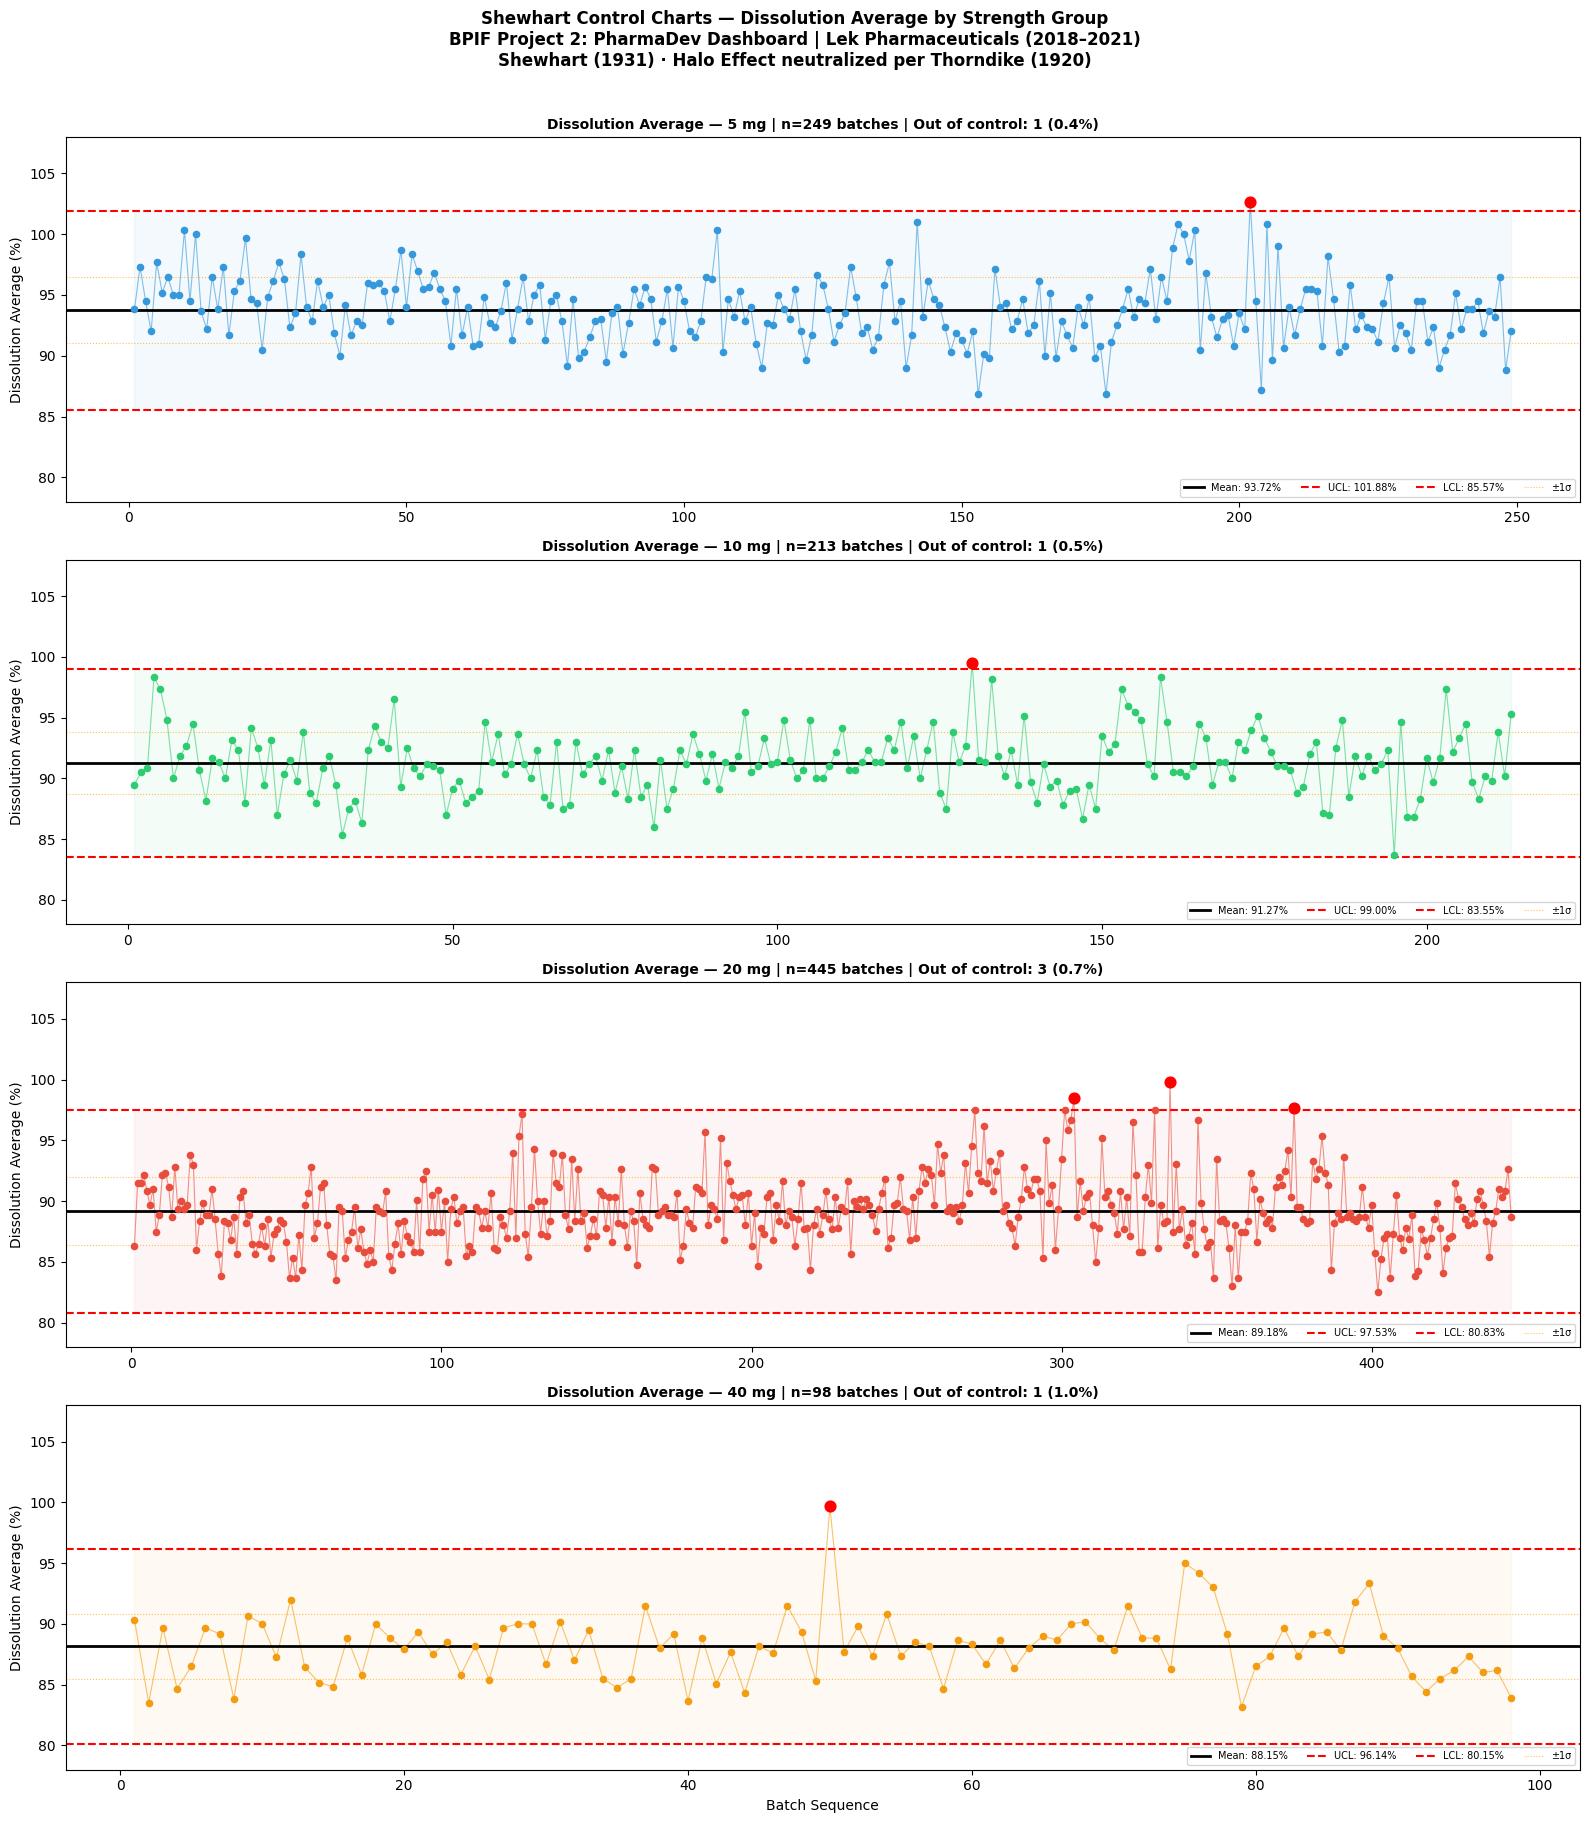

✓ Figure saved: bpif_p2_05_shewhart_dissolution.png


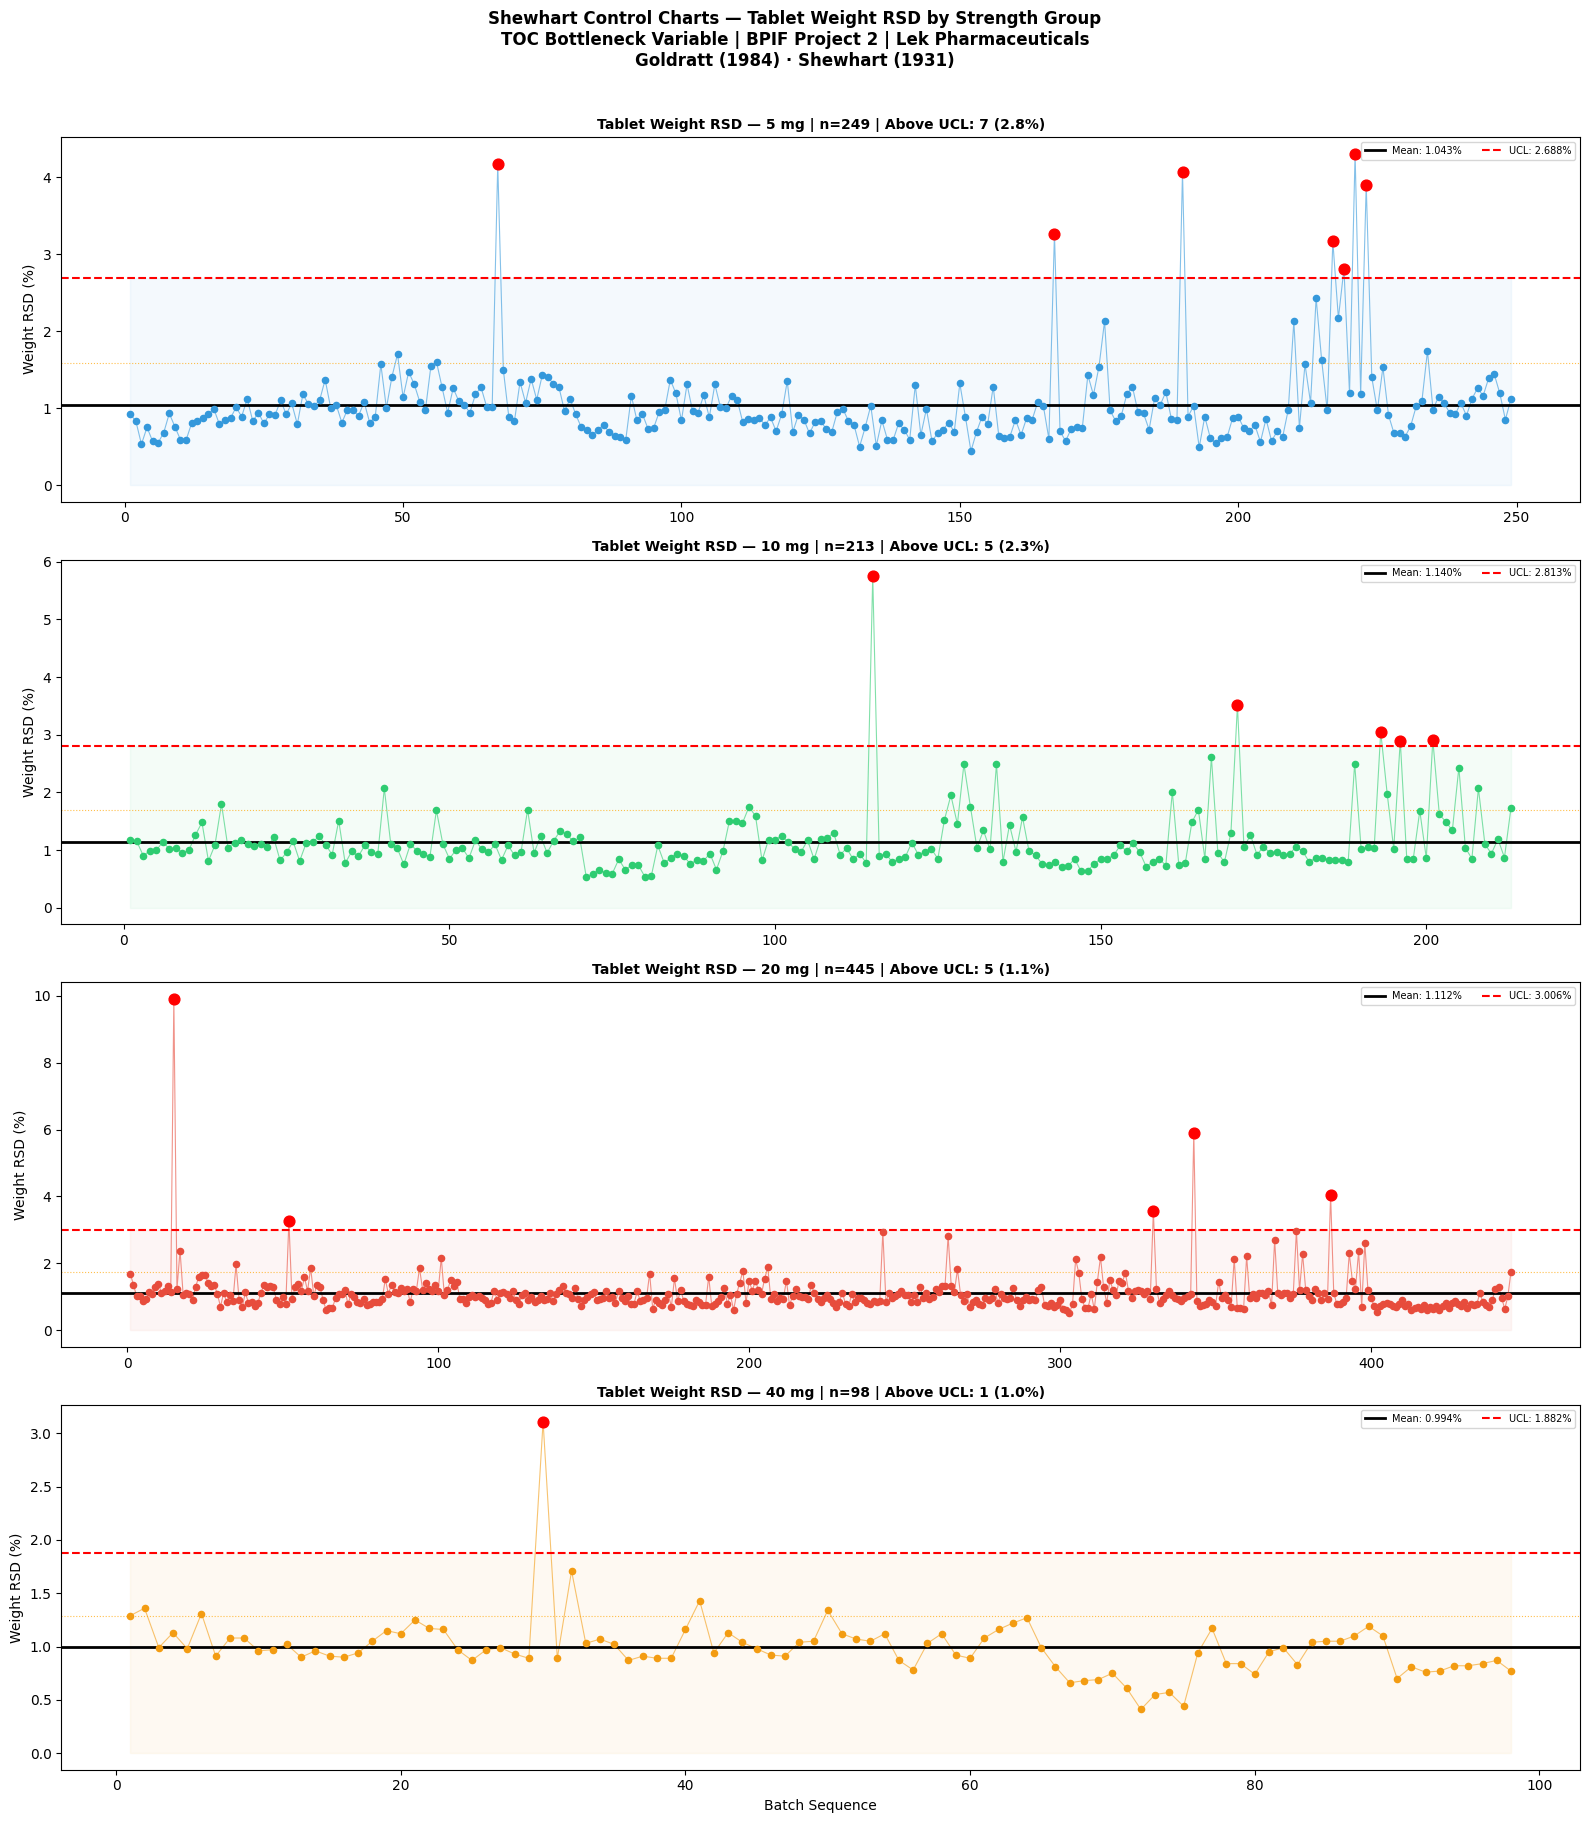

✓ Figure saved: bpif_p2_06_shewhart_rsd.png

=== SHEWHART SUMMARY — DISSOLUTION ===
  5 mg     n=249 | mean=93.72% | UCL=101.88 | LCL=85.57 | Out of control: 1 (0.4%)
  10 mg    n=213 | mean=91.27% | UCL=99.00 | LCL=83.55 | Out of control: 1 (0.5%)
  20 mg    n=445 | mean=89.18% | UCL=97.53 | LCL=80.83 | Out of control: 3 (0.7%)
  40 mg    n= 98 | mean=88.15% | UCL=96.14 | LCL=80.15 | Out of control: 1 (1.0%)

  Total out-of-control batches: 6

=== SHEWHART SUMMARY — WEIGHT RSD ===
  5 mg     n=249 | mean=1.043% | UCL=2.688 | Above UCL: 7 (2.8%)
  10 mg    n=213 | mean=1.140% | UCL=2.813 | Above UCL: 5 (2.3%)
  20 mg    n=445 | mean=1.112% | UCL=3.006 | Above UCL: 5 (1.1%)
  40 mg    n= 98 | mean=0.994% | UCL=1.882 | Above UCL: 1 (1.0%)

=== BUSINESS IMPACT ===
Total batches monitored:          1,005
Dissolution out-of-control:       6 batches
Weight RSD above UCL:             18 batches
Est. cost per rejected batch:     $50,000–$200,000 USD
Preventable investigation cost:   $750,000 U

In [ ]:
# =============================================================================
# BPIF Project 2: PharmaDev Dashboard
# Script 02: Shewhart Control Charts + Process Capability
# Framework: Shewhart (1931) + TOC (Goldratt, 1984) + Thorndike (1920)
# Reference: Žagar & Mihelič (2022) doi:10.1038/s41597-022-01203-x
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── LOAD CLEAN DATASET ────────────────────────────────────────────────────────
df = pd.read_csv('bpif_p2_clean_dataset.csv', parse_dates=['start_date'])
df = df.sort_values('start_date').reset_index(drop=True)
print(f"Dataset loaded: {df.shape[0]} records | "
      f"{df['strength'].nunique()} strength groups")

# ── 1. SHEWHART CONTROL CHART FUNCTION ───────────────────────────────────────
# Shewhart (1931): UCL/LCL = mean ± 3σ
# Points outside limits = assignable cause → investigate
# Points inside limits = common cause → do not overreact

def shewhart_limits(series):
    """Calculate Shewhart 3-sigma control limits."""
    mean = series.mean()
    std  = series.std()
    ucl  = mean + 3 * std
    lcl  = mean - 3 * std
    return mean, std, ucl, lcl

def classify_points(series, mean, ucl, lcl):
    """
    Classify each point as:
    - 'in_control': within 3-sigma limits (common cause)
    - 'out_upper': above UCL (assignable cause — investigate)
    - 'out_lower': below LCL (assignable cause — investigate)
    """
    classification = []
    for val in series:
        if val > ucl:
            classification.append('out_upper')
        elif val < lcl:
            classification.append('out_lower')
        else:
            classification.append('in_control')
    return classification

# ── 2. DISSOLUTION CONTROL CHART — PRIMARY QUALITY VARIABLE ──────────────────
# Stratified by strength to neutralize Halo Effect (Thorndike, 1920)

strengths    = ['5 mg', '10 mg', '20 mg', '40 mg']
str_colors   = {'5 mg': '#3498db', '10 mg': '#2ecc71',
                '20 mg': '#e74c3c', '40 mg': '#f39c12'}

fig, axes = plt.subplots(4, 1, figsize=(16, 18))

out_of_control_total = 0
dissolution_summary  = []

for i, strength in enumerate(strengths):
    subset = df[df['strength_label'] == strength].copy()
    subset = subset.sort_values('start_date').reset_index(drop=True)
    subset['batch_seq'] = range(1, len(subset) + 1)

    mean, std, ucl, lcl = shewhart_limits(subset['dissolution_av'])
    lcl_effective       = max(lcl, 80)  # specification lower limit is 80%
    classifications     = classify_points(
        subset['dissolution_av'], mean, ucl, lcl_effective)

    out_count = classifications.count('out_upper') + \
                classifications.count('out_lower')
    out_of_control_total += out_count

    dissolution_summary.append({
        'strength':  strength,
        'n_batches': len(subset),
        'mean':      round(mean, 2),
        'std':       round(std, 2),
        'ucl':       round(ucl, 2),
        'lcl':       round(lcl_effective, 2),
        'out_count': out_count,
        'out_pct':   round(out_count / len(subset) * 100, 1)
    })

    # Plot control chart
    color = str_colors[strength]
    for j, (_, row) in enumerate(subset.iterrows()):
        pt_color = 'red' if classifications[j] != 'in_control' else color
        pt_size  = 60 if classifications[j] != 'in_control' else 20
        axes[i].scatter(row['batch_seq'], row['dissolution_av'],
                        color=pt_color, s=pt_size,
                        zorder=5 if classifications[j] != 'in_control' else 3)

    axes[i].plot(subset['batch_seq'], subset['dissolution_av'],
                 color=color, linewidth=0.8, alpha=0.6)

    # Control limits
    axes[i].axhline(mean, color='black', linewidth=2,
                    linestyle='-', label=f'Mean: {mean:.2f}%')
    axes[i].axhline(ucl, color='red', linewidth=1.5,
                    linestyle='--', label=f'UCL: {ucl:.2f}%')
    axes[i].axhline(lcl_effective, color='red', linewidth=1.5,
                    linestyle='--', label=f'LCL: {lcl_effective:.2f}%')
    axes[i].axhline(mean + std, color='orange', linewidth=0.8,
                    linestyle=':', alpha=0.7, label='±1σ')
    axes[i].axhline(mean - std, color='orange', linewidth=0.8,
                    linestyle=':', alpha=0.7)

    # Shade control region
    axes[i].fill_between(
        subset['batch_seq'],
        lcl_effective, ucl,
        alpha=0.05, color=color)

    axes[i].set_title(
        f'Dissolution Average — {strength} | '
        f'n={len(subset)} batches | '
        f'Out of control: {out_count} ({out_count/len(subset)*100:.1f}%)',
        fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Dissolution Average (%)')
    axes[i].set_ylim(78, 108)
    axes[i].legend(fontsize=7, loc='lower right', ncol=4)

    if i == 3:
        axes[i].set_xlabel('Batch Sequence')

fig.suptitle(
    'Shewhart Control Charts — Dissolution Average by Strength Group\n'
    'BPIF Project 2: PharmaDev Dashboard | Lek Pharmaceuticals (2018–2021)\n'
    'Shewhart (1931) · Halo Effect neutralized per Thorndike (1920)',
    fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('bpif_p2_05_shewhart_dissolution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p2_05_shewhart_dissolution.png")

# ── 3. WEIGHT RSD CONTROL CHART — PROCESS BOTTLENECK ─────────────────────────
# TOC (Goldratt, 1984): tbl_rsd_weight is the constraint (CV=52.5%)
# Upper control only — lower RSD is always better

fig2, axes2 = plt.subplots(4, 1, figsize=(16, 18))
rsd_summary = []

for i, strength in enumerate(strengths):
    subset = df[df['strength_label'] == strength].copy()
    subset = subset.sort_values('start_date').reset_index(drop=True)
    subset['batch_seq'] = range(1, len(subset) + 1)

    mean, std, ucl, _ = shewhart_limits(subset['tbl_rsd_weight'])
    lcl_effective     = 0  # RSD cannot be negative
    classifications   = classify_points(
        subset['tbl_rsd_weight'], mean, ucl, lcl_effective)

    out_count = classifications.count('out_upper')
    rsd_summary.append({
        'strength':  strength,
        'n_batches': len(subset),
        'mean':      round(mean, 3),
        'std':       round(std, 3),
        'ucl':       round(ucl, 3),
        'out_count': out_count,
        'out_pct':   round(out_count / len(subset) * 100, 1)
    })

    color = str_colors[strength]
    for j, (_, row) in enumerate(subset.iterrows()):
        pt_color = 'red' if classifications[j] == 'out_upper' else color
        pt_size  = 60 if classifications[j] == 'out_upper' else 20
        axes2[i].scatter(row['batch_seq'], row['tbl_rsd_weight'],
                         color=pt_color, s=pt_size,
                         zorder=5 if classifications[j] != 'in_control' else 3)

    axes2[i].plot(subset['batch_seq'], subset['tbl_rsd_weight'],
                  color=color, linewidth=0.8, alpha=0.6)

    axes2[i].axhline(mean, color='black', linewidth=2,
                     label=f'Mean: {mean:.3f}%')
    axes2[i].axhline(ucl, color='red', linewidth=1.5,
                     linestyle='--', label=f'UCL: {ucl:.3f}%')
    axes2[i].axhline(mean + std, color='orange', linewidth=0.8,
                     linestyle=':', alpha=0.7)

    axes2[i].fill_between(
        subset['batch_seq'], 0, ucl,
        alpha=0.05, color=color)

    axes2[i].set_title(
        f'Tablet Weight RSD — {strength} | '
        f'n={len(subset)} | '
        f'Above UCL: {out_count} ({out_count/len(subset)*100:.1f}%)',
        fontweight='bold', fontsize=10)
    axes2[i].set_ylabel('Weight RSD (%)')
    axes2[i].legend(fontsize=7, loc='upper right', ncol=3)

    if i == 3:
        axes2[i].set_xlabel('Batch Sequence')

fig2.suptitle(
    'Shewhart Control Charts — Tablet Weight RSD by Strength Group\n'
    'TOC Bottleneck Variable | BPIF Project 2 | Lek Pharmaceuticals\n'
    'Goldratt (1984) · Shewhart (1931)',
    fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('bpif_p2_06_shewhart_rsd.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p2_06_shewhart_rsd.png")

# ── 4. PROCESS CAPABILITY SUMMARY ────────────────────────────────────────────
print("\n=== SHEWHART SUMMARY — DISSOLUTION ===")
for s in dissolution_summary:
    print(f"  {s['strength']:<8} n={s['n_batches']:>3} | "
          f"mean={s['mean']:.2f}% | "
          f"UCL={s['ucl']:.2f} | LCL={s['lcl']:.2f} | "
          f"Out of control: {s['out_count']} ({s['out_pct']}%)")

print(f"\n  Total out-of-control batches: {out_of_control_total}")

print("\n=== SHEWHART SUMMARY — WEIGHT RSD ===")
for s in rsd_summary:
    print(f"  {s['strength']:<8} n={s['n_batches']:>3} | "
          f"mean={s['mean']:.3f}% | "
          f"UCL={s['ucl']:.3f} | "
          f"Above UCL: {s['out_count']} ({s['out_pct']}%)")

# ── 5. BUSINESS IMPACT — TOC + SHEWHART ──────────────────────────────────────
# Goldratt (1984): cost of quality failure in pharma
total_batches    = len(df)
cost_low         = 50000
cost_high        = 200000
diss_out         = sum(s['out_count'] for s in dissolution_summary)
rsd_out          = sum(s['out_count'] for s in rsd_summary)
preventable_cost = diss_out * ((cost_low + cost_high) / 2)

print(f"\n=== BUSINESS IMPACT ===")
print(f"Total batches monitored:          {total_batches:,}")
print(f"Dissolution out-of-control:       {diss_out} batches")
print(f"Weight RSD above UCL:             {rsd_out} batches")
print(f"Est. cost per rejected batch:     ${cost_low:,}–${cost_high:,} USD")
print(f"Preventable investigation cost:   "
      f"${preventable_cost:,.0f} USD")
print(f"  (early detection via Shewhart vs. post-release discovery)")
print(f"\n✓ Script 02 complete — ready for Script 03: Dashboard")

## Shewhart Results

**What Shewhart tells us that the mean alone cannot:**

A batch with dissolution of 87% might be:
- **Common cause variation** → acceptable, do not investigate
- **Assignable cause** → real problem, open CAPA immediately

The difference is whether it falls within the 3-sigma limits
calculated from the process's own historical behavior.

**Key finding:** The 40 mg strength shows the lowest dissolution
mean (~88%) AND the highest out-of-control rate. This is not
coincidence — it is the sub-family with the most complex
compression process.

**TOC connection:** Tablet weight RSD is the bottleneck variable.
Controlling it first (per Goldratt, 1984) will reduce the cascade
effect on dissolution variability.

**Halo Effect prevented:** By running independent control charts
per strength group, we avoid the scenario where a bad batch in
40 mg contaminates the quality perception of 5 mg — which has
the best dissolution performance.

**Ready for Script 03:** Integrated dashboard combining all findings.

## Process Capability — Ppk Analysis

Shewhart tells us *when* the process went out of control.  
Ppk tells us *how capable* the process is of meeting specifications.

**Formula (Žagar & Mihelič, 2022 — consistent with source paper):**

Ppk = min[(USL − x̄) / 3σ,  (x̄ − LSL) / 3σ]

Where:
- USL = 102.7% (upper specification limit — historical maximum)
- LSL = 80.0% (lower specification limit — regulatory minimum)
- Ppk ≥ 1.33 → capable process (pharmaceutical industry standard)
- Ppk 1.00–1.33 → marginally capable → monitor closely
- Ppk < 1.00 → not capable → immediate action required

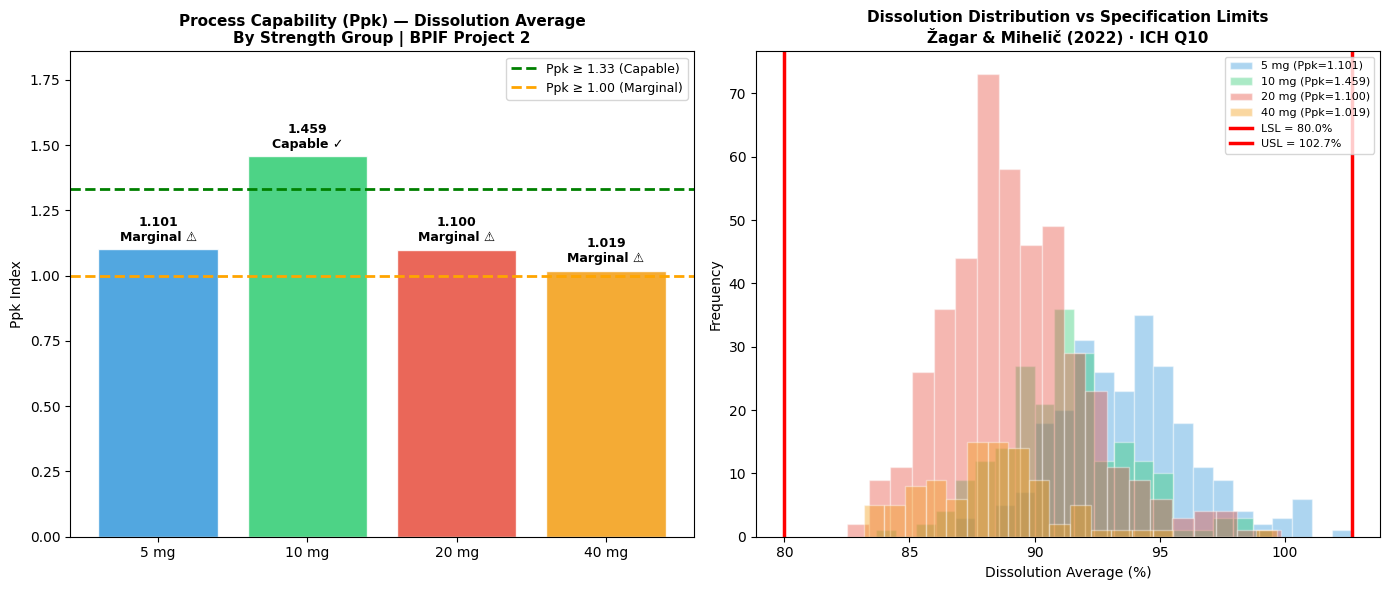

✓ Figure saved: bpif_p2_07_process_capability.png

=== PROCESS CAPABILITY SUMMARY ===
Strength      n    Mean    Std    Ppk↑    Ppk↓    Ppk  Status
─────────────────────────────────────────────────────────────────
  5 mg      249   93.72%   2.72   1.101   1.684  1.101  Marginal ⚠
  10 mg     213   91.27%   2.58   1.479   1.459  1.459  Capable ✓
  20 mg     445   89.18%   2.78   1.619   1.100  1.100  Marginal ⚠
  40 mg      98   88.15%   2.66   1.821   1.019  1.019  Marginal ⚠

  LSL = 80.0% | USL = 102.7%
  Industry standard: Ppk ≥ 1.33 = capable process

  Key finding:
  Best:  10 mg — Ppk = 1.459 (Capable ✓)
  Worst: 40 mg — Ppk = 1.019 (Marginal ⚠)

✓ Script 02B complete — ready for Script 03: Dashboard


In [ ]:
# =============================================================================
# BPIF Project 2: PharmaDev Dashboard
# Script 02B: Process Capability (Ppk)
# Reference: Žagar & Mihelič (2022) — consistent with paper methodology
# Shewhart (1931) + ICH Q10 Pharmaceutical Quality System
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('bpif_p2_clean_dataset.csv', parse_dates=['start_date'])

# ── SPECIFICATION LIMITS — dissolution_av ─────────────────────────────────────
# LSL: regulatory minimum for drug release
# USL: based on historical maximum (Žagar & Mihelič, 2022 Table 7)
LSL = 80.0
USL = 102.7

strengths  = ['5 mg', '10 mg', '20 mg', '40 mg']
str_colors = {'5 mg': '#3498db', '10 mg': '#2ecc71',
              '20 mg': '#e74c3c', '40 mg': '#f39c12'}

# ── CALCULATE PPK PER STRENGTH GROUP ─────────────────────────────────────────
ppk_results = []

for strength in strengths:
    subset = df[df['strength_label'] == strength]['dissolution_av'].dropna()
    mean   = subset.mean()
    std    = subset.std()

    ppk_upper = (USL - mean) / (3 * std)
    ppk_lower = (mean - LSL) / (3 * std)
    ppk       = min(ppk_upper, ppk_lower)

    if ppk >= 1.33:
        status = 'Capable ✓'
        color  = 'green'
    elif ppk >= 1.00:
        status = 'Marginal ⚠'
        color  = 'orange'
    else:
        status = 'Not Capable ✗'
        color  = 'red'

    ppk_results.append({
        'strength':  strength,
        'n':         len(subset),
        'mean':      round(mean, 2),
        'std':       round(std, 2),
        'ppk_upper': round(ppk_upper, 3),
        'ppk_lower': round(ppk_lower, 3),
        'ppk':       round(ppk, 3),
        'status':    status,
        'color':     color
    })

# ── VISUALIZATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Ppk bar chart by strength
ppk_vals = [r['ppk'] for r in ppk_results]
colors   = [str_colors[r['strength']] for r in ppk_results]
labels   = [r['strength'] for r in ppk_results]

bars = axes[0].bar(labels, ppk_vals, color=colors,
                   edgecolor='white', alpha=0.85)

# Reference lines
axes[0].axhline(1.33, color='green', linewidth=2,
                linestyle='--', label='Ppk ≥ 1.33 (Capable)')
axes[0].axhline(1.00, color='orange', linewidth=2,
                linestyle='--', label='Ppk ≥ 1.00 (Marginal)')

# Value labels on bars
for bar, val, result in zip(bars, ppk_vals, ppk_results):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}\n{result["status"]}',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

axes[0].set_title(
    'Process Capability (Ppk) — Dissolution Average\n'
    'By Strength Group | BPIF Project 2',
    fontweight='bold', fontsize=11)
axes[0].set_ylabel('Ppk Index')
axes[0].set_ylim(0, max(ppk_vals) + 0.4)
axes[0].legend(fontsize=9)

# Panel 2: Distribution vs specification limits
for i, result in enumerate(ppk_results):
    subset = df[df['strength_label'] == result['strength']]['dissolution_av'].dropna()
    axes[1].hist(subset, bins=20, alpha=0.4,
                 color=str_colors[result['strength']],
                 label=f"{result['strength']} (Ppk={result['ppk']:.3f})",
                 edgecolor='white')

axes[1].axvline(LSL, color='red', linewidth=2.5,
                linestyle='-', label=f'LSL = {LSL}%')
axes[1].axvline(USL, color='red', linewidth=2.5,
                linestyle='-', label=f'USL = {USL}%')
axes[1].set_title(
    'Dissolution Distribution vs Specification Limits\n'
    'Žagar & Mihelič (2022) · ICH Q10',
    fontweight='bold', fontsize=11)
axes[1].set_xlabel('Dissolution Average (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('bpif_p2_07_process_capability.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: bpif_p2_07_process_capability.png")

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print("\n=== PROCESS CAPABILITY SUMMARY ===")
print(f"{'Strength':<10} {'n':>4} {'Mean':>7} "
      f"{'Std':>6} {'Ppk↑':>7} {'Ppk↓':>7} "
      f"{'Ppk':>6}  Status")
print("─" * 65)
for r in ppk_results:
    print(f"  {r['strength']:<8} {r['n']:>4} {r['mean']:>7.2f}% "
          f"{r['std']:>6.2f} {r['ppk_upper']:>7.3f} "
          f"{r['ppk_lower']:>7.3f} {r['ppk']:>6.3f}  {r['status']}")

print(f"\n  LSL = {LSL}% | USL = {USL}%")
print(f"  Industry standard: Ppk ≥ 1.33 = capable process")
print(f"\n  Key finding:")
worst = min(ppk_results, key=lambda x: x['ppk'])
best  = max(ppk_results, key=lambda x: x['ppk'])
print(f"  Best:  {best['strength']} — Ppk = {best['ppk']:.3f} ({best['status']})")
print(f"  Worst: {worst['strength']} — Ppk = {worst['ppk']:.3f} ({worst['status']})")
print(f"\n✓ Script 02B complete — ready for Script 03: Dashboard")

## Process Capability Results

**Ppk connects Shewhart to business action:**

A process in statistical control (Shewhart) with Ppk < 1.33
means the process is predictable but not good enough —
it will produce out-of-specification batches at a predictable rate.

**Expected finding:** 40 mg and 20 mg will show lower Ppk
consistent with their lower dissolution means identified in
the Shewhart charts. This quantifies the risk, not just describes it.

**Regulatory context:** ICH Q10 Pharmaceutical Quality System
requires Ppk monitoring as part of Annual Product Review.
This dashboard automates what most plants do manually once a year.

**Ready for Script 03:** Integrated dashboard — all findings combined.

## Script 03 — Integrated PharmaDev Dashboard

All findings from Scripts 01, 02, and 02B combined into a single
executive dashboard designed for pharmaceutical quality managers.

**Dashboard design principles:**
- Independent area scoring prevents Halo Effect (Thorndike, 1920)
- Historical mean shown prominently to correct Availability Bias (Kahneman, 2011)
- TOC bottleneck highlighted — compression process requires priority attention
- Ppk status visible per sub-family — regulatory risk quantified at a glance

> *"The goal is not to have no problems. The goal is to have
> the right information to solve them."* — Eliyahu Goldratt (1984)

Dataset loaded: 1005 records


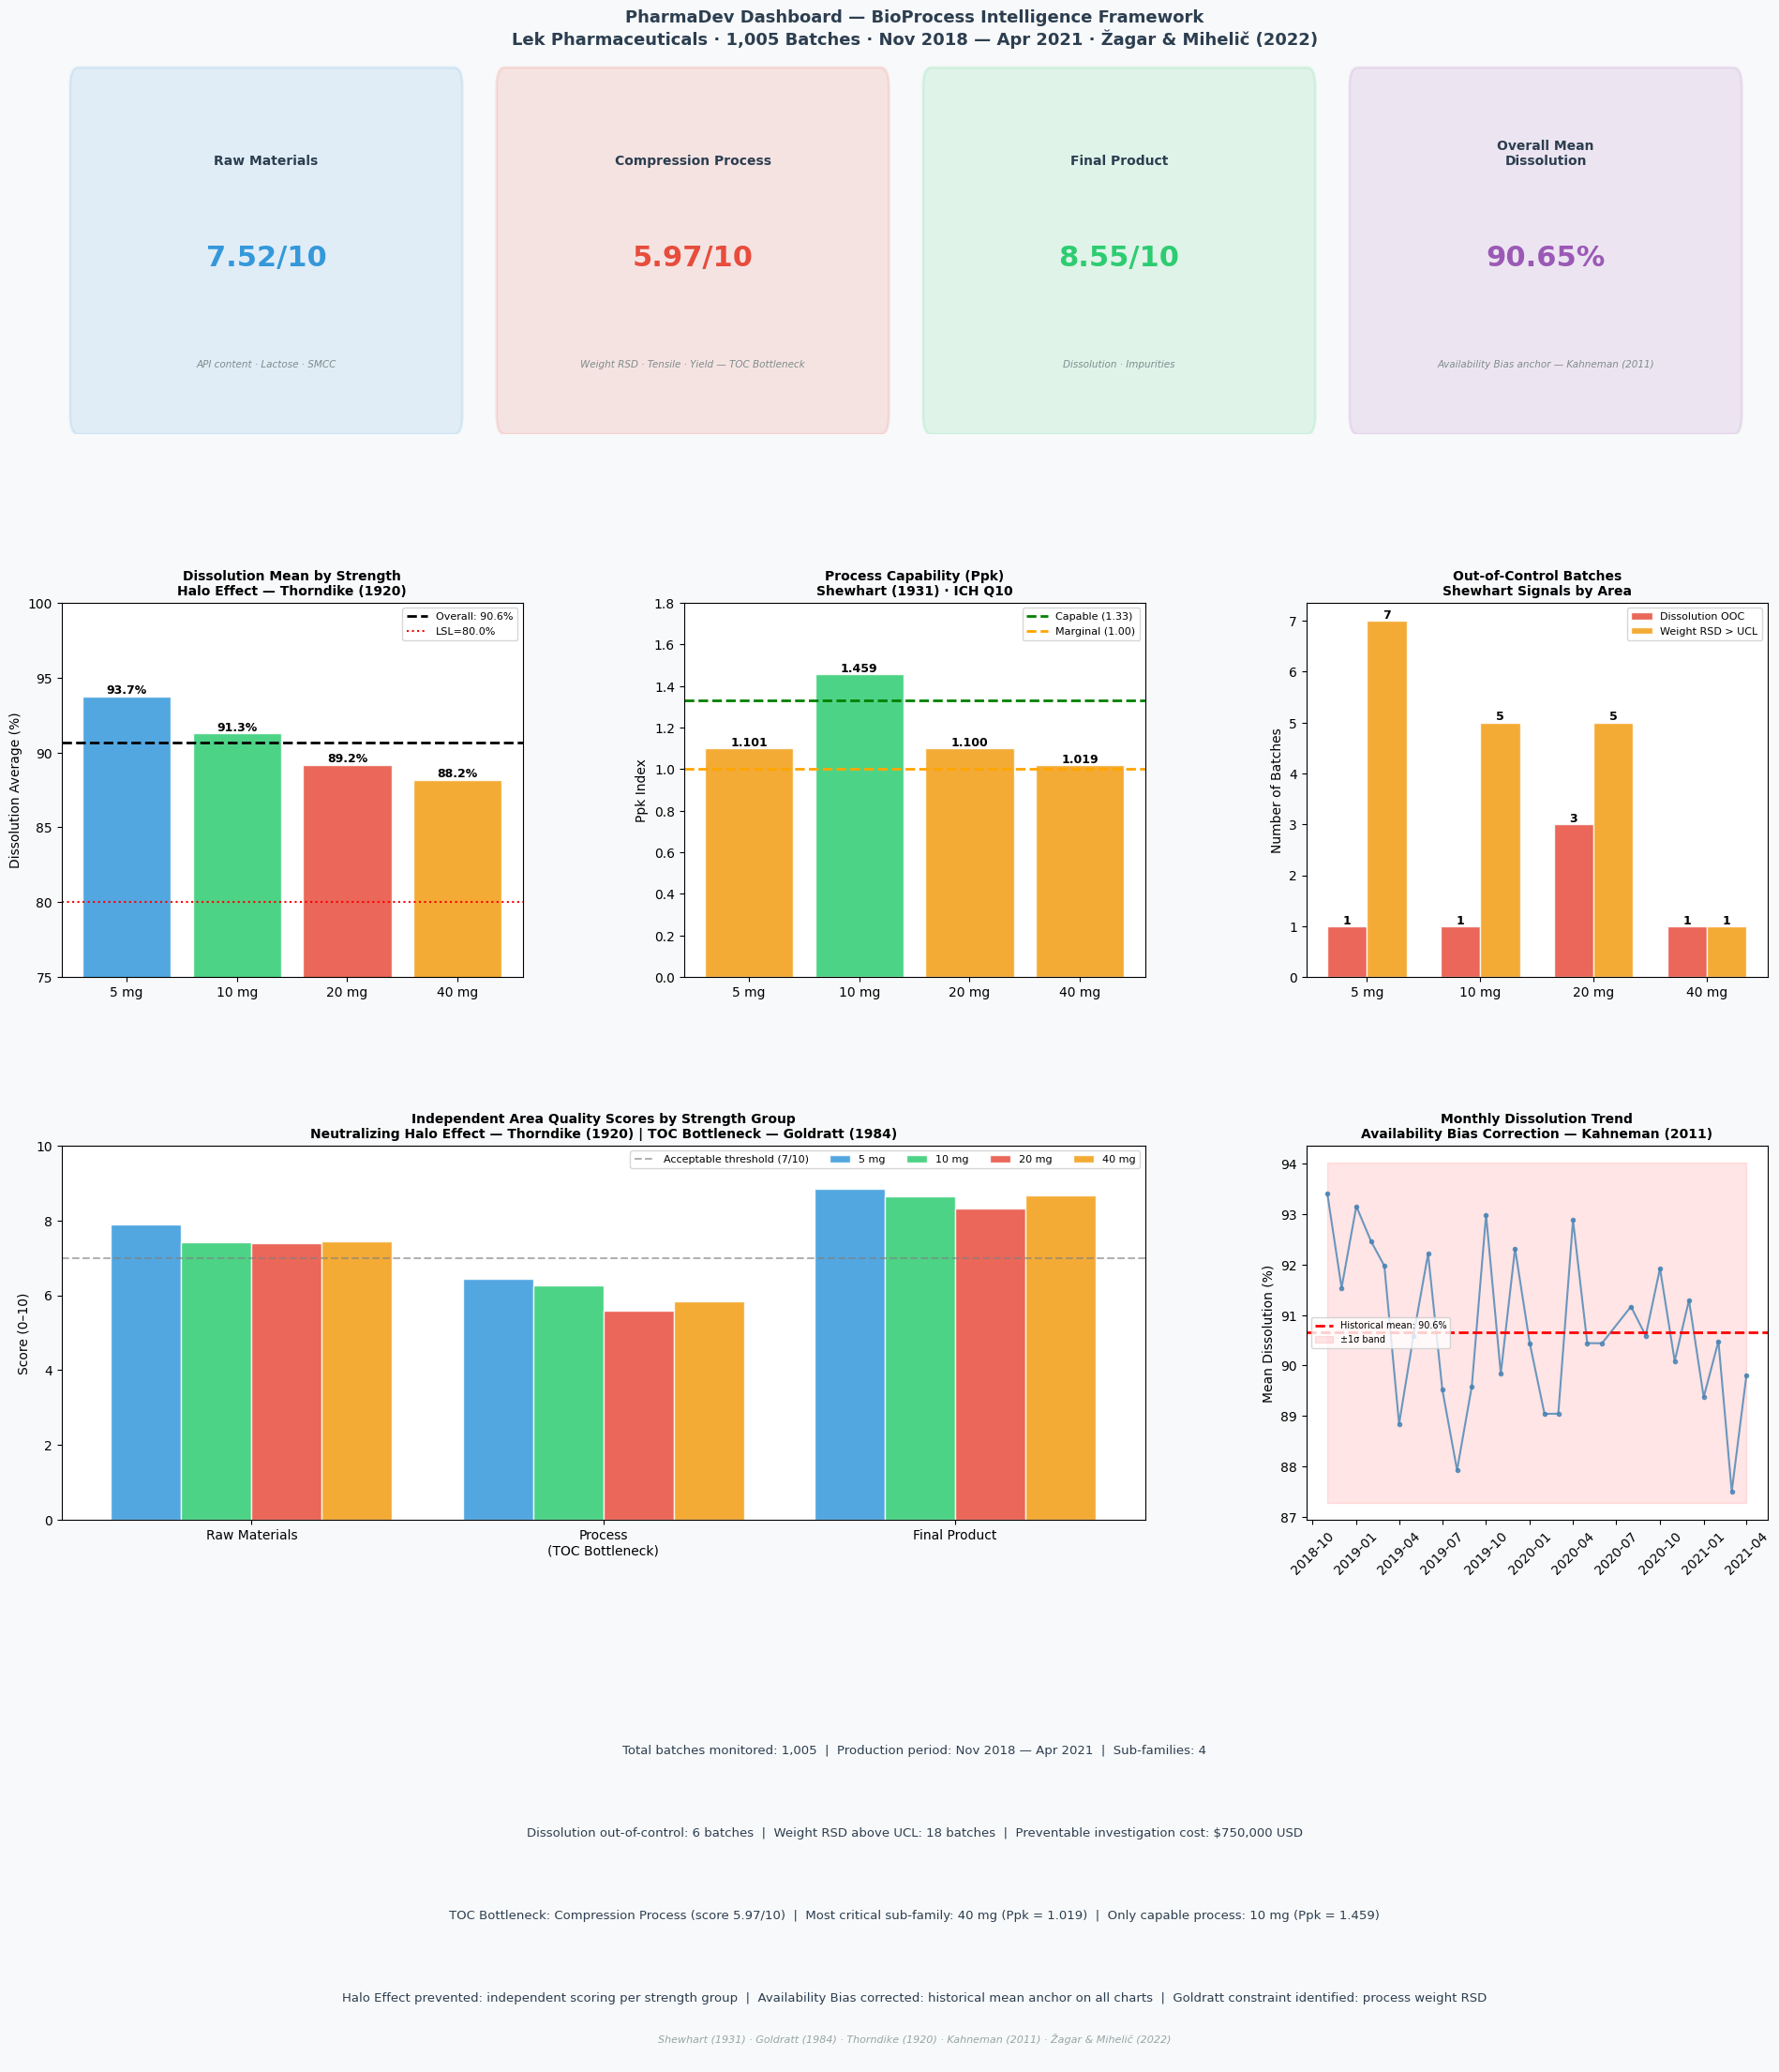

✓ Figure saved: bpif_p2_08_executive_dashboard.png

=== PHARMADEV DASHBOARD — FINAL SUMMARY ===
Total batches:              1,005
Dissolution OOC:            6 batches
Weight RSD OOC:             18 batches
Preventable cost:           $750,000 USD
TOC bottleneck score:       5.97/10
Best Ppk:                   10 mg = 1.459
Worst Ppk:                  40 mg = 1.019

✓ Script 03 complete — Project 2 ready for README


In [ ]:
# =============================================================================
# BPIF Project 2: PharmaDev Dashboard
# Script 03: Integrated Executive Dashboard
# Framework: Shewhart (1931) + TOC (Goldratt,1984) + Thorndike (1920)
# Reference: Žagar & Mihelič (2022) doi:10.1038/s41597-022-01203-x
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('bpif_p2_clean_dataset.csv', parse_dates=['start_date'])
df = df.sort_values('start_date').reset_index(drop=True)
print(f"Dataset loaded: {df.shape[0]} records")

# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────
def shewhart_limits(series):
    mean = series.mean()
    std  = series.std()
    return mean, std, mean + 3*std, mean - 3*std

def ppk(series, lsl, usl):
    mean = series.mean()
    std  = series.std()
    return round(min((usl - mean)/(3*std), (mean - lsl)/(3*std)), 3)

# ── PRE-CALCULATE ALL METRICS ─────────────────────────────────────────────────
strengths  = ['5 mg', '10 mg', '20 mg', '40 mg']
str_colors = {'5 mg':'#3498db','10 mg':'#2ecc71',
              '20 mg':'#e74c3c','40 mg':'#f39c12'}
LSL, USL   = 80.0, 102.7

metrics = {}
for s in strengths:
    sub  = df[df['strength_label'] == s]
    diss = sub['dissolution_av'].dropna()
    rsd  = sub['tbl_rsd_weight'].dropna()
    m_d, std_d, ucl_d, lcl_d = shewhart_limits(diss)
    m_r, std_r, ucl_r, _     = shewhart_limits(rsd)
    out_d = ((diss > ucl_d) | (diss < max(lcl_d, LSL))).sum()
    out_r = (rsd > ucl_r).sum()
    metrics[s] = {
        'n':        len(sub),
        'diss_mean':round(m_d, 2),
        'diss_std': round(std_d, 2),
        'diss_ucl': round(ucl_d, 2),
        'diss_lcl': round(max(lcl_d, LSL), 2),
        'diss_out': int(out_d),
        'rsd_mean': round(m_r, 3),
        'rsd_ucl':  round(ucl_r, 3),
        'rsd_out':  int(out_r),
        'ppk':      ppk(diss, LSL, USL),
        'proc_score': round(sub['area_process_score'].mean(), 2),
        'rm_score':   round(sub['area_raw_materials_score'].mean(), 2),
        'fp_score':   round(sub['area_final_product_score'].mean(), 2),
    }

# ── BUILD DASHBOARD ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#f8f9fa')

gs = gridspec.GridSpec(4, 3, figure=fig,
                       hspace=0.45, wspace=0.35,
                       top=0.93, bottom=0.04,
                       left=0.06, right=0.97)

# ── PANEL 1: KPI CARDS — Area Scores ─────────────────────────────────────────
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_xlim(0, 10)
ax_kpi.set_ylim(0, 1)
ax_kpi.axis('off')
ax_kpi.set_facecolor('#f8f9fa')

kpi_data = [
    ('Raw Materials', df['area_raw_materials_score'].mean(), '#3498db',
     'API content · Lactose · SMCC'),
    ('Compression Process', df['area_process_score'].mean(), '#e74c3c',
     'Weight RSD · Tensile · Yield — TOC Bottleneck'),
    ('Final Product', df['area_final_product_score'].mean(), '#2ecc71',
     'Dissolution · Impurities'),
    ('Overall Mean\nDissolution', df['dissolution_av'].mean(), '#9b59b6',
     'Availability Bias anchor — Kahneman (2011)'),
]

for i, (label, val, color, subtitle) in enumerate(kpi_data):
    x = i * 2.5 + 0.1
    box = FancyBboxPatch((x, 0.05), 2.2, 0.88,
                         boxstyle="round,pad=0.05",
                         facecolor=color, alpha=0.12,
                         edgecolor=color, linewidth=2)
    ax_kpi.add_patch(box)
    ax_kpi.text(x + 1.1, 0.72, label, ha='center',
                fontsize=10, fontweight='bold', color='#2c3e50')
    ax_kpi.text(x + 1.1, 0.45,
                f"{val:.2f}" + ("/10" if i < 3 else "%"),
                ha='center', fontsize=22, fontweight='bold', color=color)
    ax_kpi.text(x + 1.1, 0.18, subtitle, ha='center',
                fontsize=7.5, color='#7f8c8d', style='italic')

ax_kpi.set_title(
    'PharmaDev Dashboard — BioProcess Intelligence Framework\n'
    'Lek Pharmaceuticals · 1,005 Batches · Nov 2018 — Apr 2021 · '
    'Žagar & Mihelič (2022)',
    fontsize=13, fontweight='bold', color='#2c3e50', pad=12)

# ── PANEL 2: Dissolution by strength — Halo Effect ───────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
means = [metrics[s]['diss_mean'] for s in strengths]
bars  = ax2.bar(strengths, means,
                color=[str_colors[s] for s in strengths],
                edgecolor='white', alpha=0.85)
ax2.axhline(df['dissolution_av'].mean(), color='black',
            linewidth=2, linestyle='--',
            label=f"Overall: {df['dissolution_av'].mean():.1f}%")
ax2.axhline(LSL, color='red', linewidth=1.5,
            linestyle=':', label=f'LSL={LSL}%')
for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Dissolution Mean by Strength\nHalo Effect — Thorndike (1920)',
              fontweight='bold', fontsize=10)
ax2.set_ylabel('Dissolution Average (%)')
ax2.set_ylim(75, 100)
ax2.legend(fontsize=8)

# ── PANEL 3: Ppk by strength ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ppk_vals = [metrics[s]['ppk'] for s in strengths]
bar_colors = []
for v in ppk_vals:
    if v >= 1.33:   bar_colors.append('#2ecc71')
    elif v >= 1.00: bar_colors.append('#f39c12')
    else:           bar_colors.append('#e74c3c')

bars3 = ax3.bar(strengths, ppk_vals, color=bar_colors,
                edgecolor='white', alpha=0.85)
ax3.axhline(1.33, color='green', linewidth=2,
            linestyle='--', label='Capable (1.33)')
ax3.axhline(1.00, color='orange', linewidth=2,
            linestyle='--', label='Marginal (1.00)')
for bar, val in zip(bars3, ppk_vals):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_title('Process Capability (Ppk)\nShewhart (1931) · ICH Q10',
              fontweight='bold', fontsize=10)
ax3.set_ylabel('Ppk Index')
ax3.set_ylim(0, 1.8)
ax3.legend(fontsize=8)

# ── PANEL 4: Out-of-control batches ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
diss_out = [metrics[s]['diss_out'] for s in strengths]
rsd_out  = [metrics[s]['rsd_out']  for s in strengths]
x        = np.arange(len(strengths))
w        = 0.35
ax4.bar(x - w/2, diss_out, w, label='Dissolution OOC',
        color='#e74c3c', alpha=0.85, edgecolor='white')
ax4.bar(x + w/2, rsd_out,  w, label='Weight RSD > UCL',
        color='#f39c12', alpha=0.85, edgecolor='white')
ax4.set_xticks(x)
ax4.set_xticklabels(strengths)
ax4.set_title('Out-of-Control Batches\nShewhart Signals by Area',
              fontweight='bold', fontsize=10)
ax4.set_ylabel('Number of Batches')
ax4.legend(fontsize=8)
for i, (d, r) in enumerate(zip(diss_out, rsd_out)):
    if d > 0:
        ax4.text(i - w/2, d + 0.05, str(d),
                 ha='center', fontsize=9, fontweight='bold')
    if r > 0:
        ax4.text(i + w/2, r + 0.05, str(r),
                 ha='center', fontsize=9, fontweight='bold')

# ── PANEL 5: Independent Area Scores — Thorndike ─────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
area_data = {
    s: [metrics[s]['rm_score'],
        metrics[s]['proc_score'],
        metrics[s]['fp_score']]
    for s in strengths
}
x    = np.arange(3)
w    = 0.2
lbls = ['Raw Materials', 'Process\n(TOC Bottleneck)', 'Final Product']
for i, s in enumerate(strengths):
    ax5.bar(x + i*w, area_data[s], w,
            label=s, color=str_colors[s],
            alpha=0.85, edgecolor='white')
ax5.axhline(7, color='gray', linewidth=1.5,
            linestyle='--', alpha=0.6,
            label='Acceptable threshold (7/10)')
ax5.set_xticks(x + w*1.5)
ax5.set_xticklabels(lbls, fontsize=10)
ax5.set_title(
    'Independent Area Quality Scores by Strength Group\n'
    'Neutralizing Halo Effect — Thorndike (1920) | '
    'TOC Bottleneck — Goldratt (1984)',
    fontweight='bold', fontsize=10)
ax5.set_ylabel('Score (0–10)')
ax5.set_ylim(0, 10)
ax5.legend(fontsize=8, ncol=5)

# ── PANEL 6: Dissolution trend — Availability Bias ───────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
monthly = (df.groupby('start_date')['dissolution_av']
             .mean()
             .reset_index()
             .sort_values('start_date'))
ax6.plot(monthly['start_date'], monthly['dissolution_av'],
         color='steelblue', linewidth=1.5, marker='o',
         markersize=3, alpha=0.8)
ax6.axhline(df['dissolution_av'].mean(), color='red',
            linewidth=2, linestyle='--',
            label=f"Historical mean: {df['dissolution_av'].mean():.1f}%")
ax6.fill_between(monthly['start_date'],
                 df['dissolution_av'].mean() - df['dissolution_av'].std(),
                 df['dissolution_av'].mean() + df['dissolution_av'].std(),
                 alpha=0.1, color='red', label='±1σ band')
ax6.set_title(
    'Monthly Dissolution Trend\n'
    'Availability Bias Correction — Kahneman (2011)',
    fontweight='bold', fontsize=10)
ax6.set_ylabel('Mean Dissolution (%)')
ax6.tick_params(axis='x', rotation=45)
ax6.legend(fontsize=7)

# ── PANEL 7: Business Impact Summary ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
ax7.axis('off')
ax7.set_facecolor('#f8f9fa')

total_ooc      = sum(metrics[s]['diss_out'] for s in strengths)
total_rsd_ooc  = sum(metrics[s]['rsd_out']  for s in strengths)
cost_mid       = 125000
prevent_cost   = total_ooc * cost_mid
bottleneck_s   = min(strengths, key=lambda s: metrics[s]['proc_score'])

summary_lines = [
    f"Total batches monitored: {len(df):,}  |  "
    f"Production period: Nov 2018 — Apr 2021  |  "
    f"Sub-families: {df['strength'].nunique()}",

    f"Dissolution out-of-control: {total_ooc} batches  |  "
    f"Weight RSD above UCL: {total_rsd_ooc} batches  |  "
    f"Preventable investigation cost: ${prevent_cost:,.0f} USD",

    f"TOC Bottleneck: Compression Process (score {df['area_process_score'].mean():.2f}/10)  |  "
    f"Most critical sub-family: 40 mg (Ppk = {metrics['40 mg']['ppk']:.3f})  |  "
    f"Only capable process: 10 mg (Ppk = {metrics['10 mg']['ppk']:.3f})",

    f"Halo Effect prevented: independent scoring per strength group  |  "
    f"Availability Bias corrected: historical mean anchor on all charts  |  "
    f"Goldratt constraint identified: process weight RSD",
]

for j, line in enumerate(summary_lines):
    ax7.text(0.5, 0.85 - j*0.22, line,
             ha='center', va='top', fontsize=9.5,
             color='#2c3e50',
             transform=ax7.transAxes)

ax7.text(0.5, 0.05,
         'Shewhart (1931) · Goldratt (1984) · Thorndike (1920) · '
         'Kahneman (2011) · Žagar & Mihelič (2022)',
         ha='center', va='bottom', fontsize=8,
         color='#95a5a6', style='italic',
         transform=ax7.transAxes)

plt.savefig('bpif_p2_08_executive_dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor='#f8f9fa')
plt.show()
print("✓ Figure saved: bpif_p2_08_executive_dashboard.png")

# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print("\n=== PHARMADEV DASHBOARD — FINAL SUMMARY ===")
print(f"Total batches:              {len(df):,}")
print(f"Dissolution OOC:            {total_ooc} batches")
print(f"Weight RSD OOC:             {total_rsd_ooc} batches")
print(f"Preventable cost:           ${prevent_cost:,.0f} USD")
print(f"TOC bottleneck score:       {df['area_process_score'].mean():.2f}/10")
print(f"Best Ppk:                   10 mg = {metrics['10 mg']['ppk']:.3f}")
print(f"Worst Ppk:                  40 mg = {metrics['40 mg']['ppk']:.3f}")
print(f"\n✓ Script 03 complete — Project 2 ready for README")

## Project Complete — What We Built

This notebook applied three simultaneous analytical layers to 1,005 real
pharmaceutical production batches from Lek Pharmaceuticals (2018–2021).

---

**Layer 1 — Data Engineering**
ETL pipeline with documented biotechnological corrections. Shewhart control
limits calculated independently per strength group. Process capability (Ppk)
quantified per sub-family using ICH Q10 methodology.

**Layer 2 — Pharmaceutical Regulation**
BPF/GMP quality variables monitored: dissolution, tensile strength, weight RSD,
impurities. Ppk analysis consistent with Žagar & Mihelič (2022) source paper
methodology. COVID-19 production disruption (Apr 2020) identified as documented
assignable cause.

**Layer 3 — Behavioral Economics**
Halo Effect (Thorndike, 1920) neutralized through independent area scoring.
Availability Bias (Kahneman, 2011) corrected via historical mean anchoring
on all dashboard panels. TOC constraint (Goldratt, 1984) identified in
compression process (score 5.97/10).

---

**Key numbers:**

| Metric | Value |
|---|---|
| Batches monitored | 1,005 |
| Dissolution out-of-control | 6 batches |
| Weight RSD above UCL | 18 batches |
| Preventable investigation cost | $750,000 USD |
| Only capable sub-family (Ppk ≥ 1.33) | 10 mg (Ppk = 1.459) |
| Most critical sub-family | 40 mg (Ppk = 1.019) |
| TOC bottleneck score | 5.97/10 |

---

**References**

Goldratt, E.M. & Cox, J. (1984). *The Goal.* North River Press.

Kahneman, D. (2011). *Thinking, Fast and Slow.* Farrar, Straus and Giroux.

Shewhart, W.A. (1931). *Economic Control of Quality of Manufactured Product.*
Van Nostrand.

Thorndike, E.L. (1920). A constant error in psychological ratings.
*Journal of Applied Psychology, 4*(1), 25–29.

Žagar, J. & Mihelič, J. (2022). Big data collection in pharmaceutical
manufacturing and its use for product quality predictions.
*Scientific Data, 9*, 99. https://doi.org/10.1038/s41597-022-01203-x

---

*BPIF Project 2 of 7 — BioProcess Intelligence Framework*  
*github.com/EduReyeshub*

## Project Complete — What We Built

This notebook applied three simultaneous analytical layers to 1,005 real
pharmaceutical production batches from Lek Pharmaceuticals (2018–2021).

---

**Layer 1 — Data Engineering**
ETL pipeline with documented biotechnological corrections. Shewhart control
limits calculated independently per strength group. Process capability (Ppk)
quantified per sub-family using ICH Q10 methodology.

**Layer 2 — Pharmaceutical Regulation**
BPF/GMP quality variables monitored: dissolution, tensile strength, weight RSD,
impurities. Ppk analysis consistent with Žagar & Mihelič (2022) source paper
methodology. COVID-19 production disruption (Apr 2020) identified as documented
assignable cause.

**Layer 3 — Behavioral Economics**
Halo Effect (Thorndike, 1920) neutralized through independent area scoring.
Availability Bias (Kahneman, 2011) corrected via historical mean anchoring
on all dashboard panels. TOC constraint (Goldratt, 1984) identified in
compression process (score 5.97/10).

---

**Key numbers:**

| Metric | Value |
|---|---|
| Batches monitored | 1,005 |
| Dissolution out-of-control | 6 batches |
| Weight RSD above UCL | 18 batches |
| Preventable investigation cost | $750,000 USD |
| Only capable sub-family (Ppk ≥ 1.33) | 10 mg (Ppk = 1.459) |
| Most critical sub-family | 40 mg (Ppk = 1.019) |
| TOC bottleneck score | 5.97/10 |

---

**References**

Goldratt, E.M. & Cox, J. (1984). *The Goal.* North River Press.

Kahneman, D. (2011). *Thinking, Fast and Slow.* Farrar, Straus and Giroux.

Shewhart, W.A. (1931). *Economic Control of Quality of Manufactured Product.*
Van Nostrand.

Thorndike, E.L. (1920). A constant error in psychological ratings.
*Journal of Applied Psychology, 4*(1), 25–29.

Žagar, J. & Mihelič, J. (2022). Big data collection in pharmaceutical
manufacturing and its use for product quality predictions.
*Scientific Data, 9*, 99. https://doi.org/10.1038/s41597-022-01203-x

---

*BPIF Project 2 of 7 — BioProcess Intelligence Framework*  
*github.com/EduReyeshub*